In [ ]:
from pathlib import Path

print(Path.cwd())
print(list(Path.cwd().iterdir())[:10])

In [ ]:
from pathlib import Path
import pandas as pd
import json

folder = Path("Step 1 Files")

for f in sorted(folder.iterdir()):
    print(f.name)

In [ ]:
from pathlib import Path
import pandas as pd
import json

folder = Path("Step 1 Files")

def load_file(path):
    suffix = path.suffix.lower()

    if path.name == ".DS_Store":
        return None

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix in [".tsv", ".txt"]:
        # most of these are tab-separated
        return pd.read_csv(path, sep="\t", low_memory=False)

    if suffix == ".json":
        with open(path, "r") as f:
            data = json.load(f)
        if isinstance(data, list):
            return pd.json_normalize(data)
        elif isinstance(data, dict):
            return pd.json_normalize(data)
        else:
            return pd.DataFrame(data)

    return None


keywords = [
    "smiles", "canonical", "inchi", "inchikey",
    "pubchem", "cid", "compound", "drug",
    "pert", "name", "moa", "target"
]

inventory = []

for path in sorted(folder.iterdir()):
    if path.name == ".DS_Store":
        continue

    try:
        df = load_file(path)
        if df is None:
            continue

        matching_cols = [
            col for col in df.columns
            if any(k in str(col).lower() for k in keywords)
        ]

        inventory.append({
            "file": path.name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "matching_columns": matching_cols
        })

    except Exception as e:
        inventory.append({
            "file": path.name,
            "error": str(e)
        })

inventory_df = pd.DataFrame(inventory)
inventory_df

In [ ]:
for item in inventory:
    print("\n" + "="*80)
    print(item["file"])
    
    if "error" in item:
        print("ERROR:", item["error"])
    else:
        print("Rows:", item["rows"])
        print("Columns:", item["columns"])
        print("Matching columns:")
        for col in item["matching_columns"]:
            print("  -", col)

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

inventory_df

In [ ]:
inventory_df.to_csv("step1_file_inventory.csv", index=False)

In [ ]:
for path in sorted(folder.iterdir()):
    if path.name == ".DS_Store":
        continue
    
    print("\n" + "="*100)
    print(path.name)
    
    df = load_file(path)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    
    display(df.head(3))

In [ ]:
from pathlib import Path
import pandas as pd
import json
import numpy as np

folder = Path("Step 1 Files")

def load_file(path):
    suffix = path.suffix.lower()

    if path.name == ".DS_Store":
        return None

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix in [".tsv", ".txt"]:
        return pd.read_csv(path, sep="\t", low_memory=False)

    if suffix == ".json":
        with open(path, "r") as f:
            data = json.load(f)
        if isinstance(data, list):
            return pd.json_normalize(data)
        elif isinstance(data, dict):
            return pd.json_normalize(data)

    return None


def pick_col(df, candidates):
    lower_map = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def get_series(df, col):
    if col is not None:
        return df[col]
    else:
        return pd.Series(pd.NA, index=df.index)


records = []

for path in sorted(folder.iterdir()):
    if path.name == ".DS_Store":
        continue

    df = load_file(path)
    if df is None:
        continue

    source = path.stem

    name_col = pick_col(df, [
        "drug_name", "compound_name", "pert_name", "pert_iname",
        "pubchem_title", "name", "drug", "lincs_drug_name",
        "nibr_drug_name", "tahoe_drug_name", "creeds_drug_name",
        "deepcover_drug_name", "rummageo_drug_name", "sciplex_drug_name",
        "cmap_drug_name"
    ])

    smiles_col = pick_col(df, [
        "smiles", "canonical_smiles"
    ])

    inchi_col = pick_col(df, [
        "inchi", "inchi_key", "inchikey", "drh_inchi_key"
    ])

    cid_col = pick_col(df, [
        "pubchem_cid", "pubchem_id", "cid", "pubchem"
    ])

    moa_col = pick_col(df, [
        "moa", "drh_moa", "moa-broad", "moa_broad", "moabox_moa",
        "moa-fine", "moa_fine"
    ])

    target_col = pick_col(df, [
        "target", "targets", "drh_target"
    ])

    pert_id_col = pick_col(df, [
        "pert_id", "pert_ids", "perturb_id", "lincs_pert_id"
    ])

    temp = pd.DataFrame({
        "source": pd.Series(source, index=df.index),
        "compound_name": get_series(df, name_col),
        "smiles": get_series(df, smiles_col),
        "inchi_key": get_series(df, inchi_col),
        "pubchem_cid": get_series(df, cid_col),
        "moa": get_series(df, moa_col),
        "target": get_series(df, target_col),
        "pert_id": get_series(df, pert_id_col),
    })

    records.append(temp)

registry_raw = pd.concat(records, ignore_index=True)

registry_raw.head()

In [ ]:
registry = registry_raw.copy()

for col in ["compound_name", "smiles", "inchi_key", "pubchem_cid", "moa", "target", "pert_id"]:
    registry[col] = registry[col].astype("string").str.strip()

registry = registry.replace({
    "": pd.NA,
    "nan": pd.NA,
    "None": pd.NA,
    "NA": pd.NA,
    "N/A": pd.NA,
    "-": pd.NA
})

print("Total rows:", len(registry))
print("Rows with SMILES:", registry["smiles"].notna().sum())
print("Rows with PubChem CID:", registry["pubchem_cid"].notna().sum())
print("Rows with InChIKey:", registry["inchi_key"].notna().sum())

registry.head()

In [ ]:
from rdkit import Chem
import pandas as pd

registry_with_smiles = registry[
    registry["smiles"].notna() &
    (registry["smiles"].astype(str).str.strip() != "")
].copy()

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return pd.NA
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return pd.NA

registry_with_smiles["canonical_smiles"] = registry_with_smiles["smiles"].apply(canonicalize_smiles)

print("Rows before canonicalization:", len(registry_with_smiles))
print("Rows with valid canonical SMILES:", registry_with_smiles["canonical_smiles"].notna().sum())
print("Invalid SMILES:", registry_with_smiles["canonical_smiles"].isna().sum())
print("Unique canonical SMILES:", registry_with_smiles["canonical_smiles"].nunique())

In [ ]:
valid_registry = registry_with_smiles[
    registry_with_smiles["canonical_smiles"].notna()
].copy()

def collapse_unique(series):
    vals = (
        series.dropna()
        .astype(str)
        .str.strip()
    )
    vals = vals[~vals.isin(["", "nan", "None", "<NA>", "NA", "N/A", "-"])]
    unique_vals = sorted(vals.unique())
    return "; ".join(unique_vals) if len(unique_vals) > 0 else pd.NA

compound_registry_clean = (
    valid_registry
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "source": collapse_unique,
        "compound_name": collapse_unique,
        "smiles": collapse_unique,
        "inchi_key": collapse_unique,
        "pubchem_cid": collapse_unique,
        "moa": collapse_unique,
        "target": collapse_unique,
        "pert_id": collapse_unique,
    })
)

print("Clean unique compounds:", len(compound_registry_clean))
compound_registry_clean.head()

In [ ]:
compound_registry_clean.to_csv("step1_compound_registry_clean.csv", index=False)

print("Saved clean registry:")
print("step1_compound_registry_clean.csv")

In [ ]:
from pathlib import Path

folder = Path("Step 1 Files")

list(folder.glob("*chembl*")), list(folder.glob("*CID*"))

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

folder = Path("Step 1 Files")

chembl_path = list(folder.glob("chembl*_chemreps*.txt.gz"))[0]
pubchem_path = list(folder.glob("CID-SMILES*.gz"))[0]

print("ChEMBL:", chembl_path)
print("PubChem:", pubchem_path)

In [ ]:
chembl = pd.read_csv(chembl_path, sep="\t", compression="gzip", low_memory=False)

print(chembl.shape)
print(chembl.columns.tolist())
chembl.head()

In [ ]:
chembl_registry = pd.DataFrame({
    "source": "ChEMBL_37",
    "compound_name": chembl.get("chembl_id", pd.NA),
    "smiles": chembl.get("canonical_smiles", pd.NA),
    "inchi_key": chembl.get("standard_inchi_key", pd.NA),
    "pubchem_cid": pd.NA,
    "moa": pd.NA,
    "target": pd.NA,
    "pert_id": chembl.get("chembl_id", pd.NA),
})

chembl_registry.head()

In [ ]:
N_PUBCHEM = 1_000_000  # increase to 2_000_000 or 5_000_000 later if laptop is fine

pubchem = pd.read_csv(
    pubchem_path,
    sep=r"\s+",
    compression="gzip",
    header=None,
    names=["pubchem_cid", "smiles"],
    nrows=N_PUBCHEM
)

print(pubchem.shape)
pubchem.head()

In [ ]:
pubchem_registry = pd.DataFrame({
    "source": "PubChem_CID_SMILES",
    "compound_name": pd.NA,
    "smiles": pubchem["smiles"],
    "inchi_key": pd.NA,
    "pubchem_cid": pubchem["pubchem_cid"],
    "moa": pd.NA,
    "target": pd.NA,
    "pert_id": pd.NA,
})

pubchem_registry.head()

In [ ]:
existing_registry = pd.read_csv("step1_compound_registry_clean.csv")

# Make sure existing registry has the same columns
needed_cols = ["source", "compound_name", "smiles", "inchi_key", "pubchem_cid", "moa", "target", "pert_id"]

for col in needed_cols:
    if col not in existing_registry.columns:
        existing_registry[col] = pd.NA

existing_registry = existing_registry[needed_cols]
chembl_registry = chembl_registry[needed_cols]
pubchem_registry = pubchem_registry[needed_cols]

expanded_raw = pd.concat(
    [existing_registry, chembl_registry, pubchem_registry],
    ignore_index=True
)

print("Existing registry:", len(existing_registry))
print("ChEMBL added:", len(chembl_registry))
print("PubChem added:", len(pubchem_registry))
print("Expanded raw total:", len(expanded_raw))
expanded_raw.head()

In [ ]:
from rdkit import Chem

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return pd.NA
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return pd.NA

expanded_raw = expanded_raw[
    expanded_raw["smiles"].notna() &
    (expanded_raw["smiles"].astype(str).str.strip() != "")
].copy()

expanded_raw["canonical_smiles"] = expanded_raw["smiles"].apply(canonicalize_smiles)

print("Rows before RDKit filtering:", len(expanded_raw))
print("Valid canonical SMILES:", expanded_raw["canonical_smiles"].notna().sum())
print("Invalid SMILES:", expanded_raw["canonical_smiles"].isna().sum())
print("Unique canonical SMILES:", expanded_raw["canonical_smiles"].nunique())

In [ ]:
valid_expanded = expanded_raw[expanded_raw["canonical_smiles"].notna()].copy()

def collapse_unique(series):
    vals = series.dropna().astype(str).str.strip()
    vals = vals[~vals.isin(["", "nan", "None", "<NA>", "NA", "N/A", "-"])]
    unique_vals = sorted(vals.unique())
    return "; ".join(unique_vals) if len(unique_vals) > 0 else pd.NA

expanded_registry_clean = (
    valid_expanded
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "source": collapse_unique,
        "compound_name": collapse_unique,
        "smiles": collapse_unique,
        "inchi_key": collapse_unique,
        "pubchem_cid": collapse_unique,
        "moa": collapse_unique,
        "target": collapse_unique,
        "pert_id": collapse_unique,
    })
)

print("Expanded clean unique compounds:", len(expanded_registry_clean))
expanded_registry_clean.head()

In [ ]:
valid_expanded = expanded_raw[expanded_raw["canonical_smiles"].notna()].copy()

# Prefer rows from curated perturbation datasets over giant PubChem rows
def get_priority(source):
    source = str(source).lower()
    if "pubchem" in source:
        return 3
    elif "chembl" in source:
        return 2
    else:
        return 1

valid_expanded["source_priority"] = valid_expanded["source"].apply(get_priority)

# Prefer rows that have more useful metadata
valid_expanded["has_name"] = valid_expanded["compound_name"].notna().astype(int)
valid_expanded["has_moa"] = valid_expanded["moa"].notna().astype(int)
valid_expanded["has_target"] = valid_expanded["target"].notna().astype(int)
valid_expanded["has_inchi"] = valid_expanded["inchi_key"].notna().astype(int)
valid_expanded["has_pubchem"] = valid_expanded["pubchem_cid"].notna().astype(int)

valid_expanded_sorted = valid_expanded.sort_values(
    by=[
        "source_priority",
        "has_moa",
        "has_target",
        "has_name",
        "has_inchi",
        "has_pubchem"
    ],
    ascending=[True, False, False, False, False, False]
)

expanded_registry_clean = (
    valid_expanded_sorted
    .drop_duplicates(subset="canonical_smiles", keep="first")
    .drop(columns=[
        "source_priority",
        "has_name",
        "has_moa",
        "has_target",
        "has_inchi",
        "has_pubchem"
    ])
    .reset_index(drop=True)
)

print("Expanded clean unique compounds:", len(expanded_registry_clean))
expanded_registry_clean.head()

In [ ]:
expanded_registry_clean.to_csv("step1_compound_registry_expanded_clean_fast.csv", index=False)

print("Saved fast clean registry:")
print("step1_compound_registry_expanded_clean_fast.csv")

In [ ]:
import gzip
from pathlib import Path

folder = Path("Step 1 Files")
pubchem_path = list(folder.glob("CID-SMILES*.gz"))[0]

total_pubchem_rows = 0
with gzip.open(pubchem_path, "rt") as f:
    for _ in f:
        total_pubchem_rows += 1

print("Total PubChem rows in file:", total_pubchem_rows)
print("PubChem rows used:", N_PUBCHEM)
print("PubChem rows left out:", total_pubchem_rows - N_PUBCHEM)

In [ ]:
from pathlib import Path

summary = """
Step 1 Compound Registry Expansion

Goal:
Build compound registry for compound → compound autoencoder.

Sources used:
- PerturbSeqr drug metadata
- LINCS small molecules
- Drug Repurposing Hub
- CREEDS chemical perturbations
- Novartis DRUG-seq metadata
- Tahoe 100M metadata
- L1000-CP drug metadata
- CMAP/microarray drug metadata
- SciPlex drug metadata
- DeepCoverMOA drug metadata
- RummaGEO chemical drug metadata
- ChEMBL 37 chemreps
- PubChem CID-SMILES subset

Key outputs:
- step1_compound_registry_clean.csv
- step1_compound_registry_expanded_clean_fast.csv

Current expanded clean registry:
- 3,765,890 unique valid canonical SMILES

Important note:
Only 1,000,000 rows from PubChem CID-SMILES were used for computational feasibility.
Full PubChem CID-SMILES file contained 123,994,425 rows.
"""

Path("step1_registry_summary.txt").write_text(summary)

print("Saved step1_registry_summary.txt")

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import MACCSkeys, rdMolDescriptors
from numpy.lib.format import open_memmap
import time

# Paths
registry_path = Path("step1_compound_registry_expanded_clean_fast.csv")
out_dir = Path("step1_fingerprints")
out_dir.mkdir(exist_ok=True)

print("Registry exists:", registry_path.exists())
print("Output folder:", out_dir)

In [ ]:
try:
    from rdkit.Avalon import pyAvalonTools
    HAS_AVALON = True
    print("Avalon available.")
except ImportError:
    HAS_AVALON = False
    print("Avalon NOT available. Will skip Avalon fingerprint.")

In [ ]:
registry = pd.read_csv(registry_path, usecols=["canonical_smiles"])

smiles = registry["canonical_smiles"].dropna().astype(str).tolist()
n = len(smiles)

print("Number of SMILES:", n)
print(smiles[:5])

In [ ]:
fp_specs = {
    "morgan": 2048,
    "maccs": 167,
    "torsion": 2048,
    "pattern": 2048,
}

if HAS_AVALON:
    fp_specs["avalon"] = 512

packed_specs = {
    name: int(np.ceil(n_bits / 8))
    for name, n_bits in fp_specs.items()
}

print("Fingerprint bit dimensions:", fp_specs)
print("Packed byte dimensions:", packed_specs)
print("Approx packed total GB:", sum(n * b for b in packed_specs.values()) / 1e9)

In [ ]:
fingerprint_arrays = {}

for name, n_bytes in packed_specs.items():
    path = out_dir / f"step1_{name}_packed.npy"
    fingerprint_arrays[name] = open_memmap(
        path,
        mode="w+",
        dtype=np.uint8,
        shape=(n, n_bytes)
    )
    print(name, fingerprint_arrays[name].shape, path)

In [ ]:
def fp_to_packed(fp, n_bits):
    arr = np.zeros((n_bits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return np.packbits(arr)


def make_fingerprints(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None

    fps = {}

    morgan = rdMolDescriptors.GetMorganFingerprintAsBitVect(
        mol, radius=2, nBits=2048
    )
    fps["morgan"] = fp_to_packed(morgan, 2048)

    maccs = MACCSkeys.GenMACCSKeys(mol)
    fps["maccs"] = fp_to_packed(maccs, 167)

    torsion = rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(
        mol, nBits=2048
    )
    fps["torsion"] = fp_to_packed(torsion, 2048)

    pattern = Chem.PatternFingerprint(mol, fpSize=2048)
    fps["pattern"] = fp_to_packed(pattern, 2048)

    if HAS_AVALON:
        avalon = pyAvalonTools.GetAvalonFP(mol, nBits=512)
        fps["avalon"] = fp_to_packed(avalon, 512)

    return fps

In [ ]:
for smi in smiles[:5]:
    fps = make_fingerprints(smi)
    print(smi)
    if fps is None:
        print("FAILED")
    else:
        for k, v in fps.items():
            print(" ", k, v.shape)

In [ ]:
valid_mask = np.zeros(n, dtype=bool)
failed = []

start_time = time.time()

for i, smi in enumerate(smiles):
    fps = make_fingerprints(smi)

    if fps is None:
        failed.append((i, smi))
        continue

    for name, arr in fps.items():
        fingerprint_arrays[name][i, :] = arr

    valid_mask[i] = True

    if (i + 1) % 10000 == 0:
        elapsed = time.time() - start_time
        rate = (i + 1) / elapsed
        remaining = (n - (i + 1)) / rate / 60
        print(
            f"Processed {i+1:,}/{n:,} | "
            f"valid: {valid_mask.sum():,} | "
            f"failed: {len(failed):,} | "
            f"~{remaining:.1f} min remaining"
        )

# Flush files to disk
for arr in fingerprint_arrays.values():
    arr.flush()

np.save(out_dir / "step1_valid_fingerprint_mask.npy", valid_mask)

failed_df = pd.DataFrame(failed, columns=["row_index", "canonical_smiles"])
failed_df.to_csv(out_dir / "step1_failed_fingerprints.csv", index=False)

print("DONE")
print("Valid fingerprints:", valid_mask.sum())
print("Failed:", len(failed))

In [4]:
# Step 1 Fingerprint Generation

Generated packed molecular fingerprints for 3,765,890 compounds from `step1_compound_registry_expanded_clean_fast.csv`.

Saved outputs under `data/step1_fingerprints/`:
- Morgan fingerprints
- MACCS keys
- Avalon fingerprints
- topological torsion fingerprints
- pattern fingerprints
- valid fingerprint mask
- matched fingerprinted compound registry

All 3,765,890 compounds produced valid fingerprints.

SyntaxError: invalid syntax (852959122.py, line 3)

In [5]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import torch
from torch import nn

# 
# Config
# 
FP_DIR = Path("step1_fingerprints")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

EPOCHS = 50
BATCH_SIZE = 512
LATENT_DIM = 128
LR = 1e-3
SEED = 42
VAL_MAX_ROWS = 100_000  # use subset for validation speed

torch.manual_seed(SEED)
np.random.seed(SEED)

print("PyTorch:", torch.__version__)
print("FP_DIR exists:", FP_DIR.exists())
print("MODEL_DIR:", MODEL_DIR)

PyTorch: 2.12.1
FP_DIR exists: True
MODEL_DIR: ../models


In [6]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [7]:
fingerprint_files = {
    "maccs": FP_DIR / "step1_maccs_packed.npy",
    "morgan": FP_DIR / "step1_morgan_packed.npy",
    "avalon": FP_DIR / "step1_avalon_packed.npy",
    "torsion": FP_DIR / "step1_torsion_packed.npy",
    "pattern": FP_DIR / "step1_pattern_packed.npy",
}

fingerprint_bits = {
    "maccs": 167,
    "morgan": 2048,
    "avalon": 512,
    "torsion": 2048,
    "pattern": 2048,
}

arrays = {
    name: np.load(path, mmap_mode="r")
    for name, path in fingerprint_files.items()
}

n_total = arrays["morgan"].shape[0]
input_dim = sum(fingerprint_bits.values())

print("Total compounds:", n_total)
print("Input dimension:", input_dim)

for name, arr in arrays.items():
    print(name, arr.shape)

Total compounds: 3765890
Input dimension: 6823
maccs (3765890, 21)
morgan (3765890, 256)
avalon (3765890, 64)
torsion (3765890, 256)
pattern (3765890, 256)


In [8]:
rng = np.random.default_rng(SEED)

indices = np.arange(n_total)
rng.shuffle(indices)

n_train = int(0.80 * n_total)
n_val = int(0.10 * n_total)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))

np.savez(
    FP_DIR / f"step1_split_80_10_10_seed{SEED}.npz",
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)

Train: 3012712
Val: 376589
Test: 376589


In [9]:
fp_order = ["maccs", "morgan", "avalon", "torsion", "pattern"]

def make_batch(batch_indices):
    parts = []

    for name in fp_order:
        packed = arrays[name][batch_indices]
        bits = np.unpackbits(packed, axis=1)[:, :fingerprint_bits[name]]
        parts.append(bits)

    x = np.concatenate(parts, axis=1).astype(np.float32, copy=False)
    return torch.from_numpy(x).to(device)

In [10]:
class CompoundAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 2048),
            nn.ReLU(),
            nn.Linear(2048, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        logits = self.decoder(z)
        return logits, z


model = CompoundAutoencoder(input_dim=input_dim, latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

print(model)

CompoundAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=6823, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=2048, bias=True)
    (3): ReLU()
    (4): Linear(in_features=2048, out_features=6823, bias=True)
  )
)


In [11]:
def evaluate(eval_idx, max_rows=VAL_MAX_ROWS):
    model.eval()

    if max_rows is not None and len(eval_idx) > max_rows:
        eval_idx = rng.choice(eval_idx, size=max_rows, replace=False)

    total_loss = 0.0
    total_bits_correct = 0
    total_bits = 0
    total_rows = 0

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_batch(batch_idx)

            logits, _ = model(x)
            loss = criterion(logits, x)

            preds = torch.sigmoid(logits) > 0.5
            truth = x > 0.5

            total_bits_correct += (preds == truth).sum().item()
            total_bits += truth.numel()

            total_loss += loss.item() * len(batch_idx)
            total_rows += len(batch_idx)

    return total_loss / total_rows, total_bits_correct / total_bits

In [12]:
small_batch = train_idx[:BATCH_SIZE]
x = make_batch(small_batch)

logits, z = model(x)
loss = criterion(logits, x)

print("Batch shape:", x.shape)
print("Latent shape:", z.shape)
print("Initial loss:", loss.item())

Batch shape: torch.Size([512, 6823])
Latent shape: torch.Size([512, 128])
Initial loss: 0.6933199763298035


In [13]:
best_val_loss = float("inf")
metrics = []

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    model.train()

    rng.shuffle(train_idx)

    train_loss_sum = 0.0
    train_rows = 0

    for batch_num, start in enumerate(range(0, len(train_idx), BATCH_SIZE), start=1):
        batch_idx = train_idx[start:start+BATCH_SIZE]
        x = make_batch(batch_idx)

        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(x)
        loss = criterion(logits, x)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * len(batch_idx)
        train_rows += len(batch_idx)

        # minimal progress printing
        if batch_num % 1000 == 0:
            print(
                f"Epoch {epoch:02d} | batch {batch_num:,} | "
                f"train BCE so far: {train_loss_sum/train_rows:.6f}"
            )

    train_loss = train_loss_sum / train_rows
    val_loss, val_acc = evaluate(val_idx, max_rows=VAL_MAX_ROWS)

    elapsed_min = (time.time() - epoch_start) / 60

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_bitwise_accuracy": val_acc,
        "elapsed_min": elapsed_min,
        "latent_dim": LATENT_DIM,
        "batch_size": BATCH_SIZE,
        "lr": LR,
    }

    metrics.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train BCE: {train_loss:.6f} | "
        f"val BCE: {val_loss:.6f} | "
        f"val acc: {val_acc:.4f} | "
        f"time: {elapsed_min:.1f} min"
    )

    # Save latest model every epoch
    latest_path = MODEL_DIR / f"step1_compound_autoencoder_latent{LATENT_DIM}_latest.pt"

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "input_dim": input_dim,
        "latent_dim": LATENT_DIM,
        "fingerprint_order": fp_order,
        "fingerprint_bits": fingerprint_bits,
        "split": "80/10/10",
        "seed": SEED,
    }, latest_path)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_path = MODEL_DIR / f"step1_compound_autoencoder_latent{LATENT_DIM}_best.pt"

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "input_dim": input_dim,
            "latent_dim": LATENT_DIM,
            "fingerprint_order": fp_order,
            "fingerprint_bits": fingerprint_bits,
            "split": "80/10/10",
            "seed": SEED,
            "best_val_loss": best_val_loss,
        }, best_path)

        print("Saved new best model:", best_path)

    # Save metrics every epoch
    pd.DataFrame(metrics).to_csv(
        MODEL_DIR / f"step1_compound_autoencoder_latent{LATENT_DIM}_metrics.csv",
        index=False
    )

print("Training complete.")

Epoch 01 | batch 1,000 | train BCE so far: 0.108809
Epoch 01 | batch 2,000 | train BCE so far: 0.085464
Epoch 01 | batch 3,000 | train BCE so far: 0.073582
Epoch 01 | batch 4,000 | train BCE so far: 0.066339
Epoch 01 | batch 5,000 | train BCE so far: 0.061164
Epoch 01/50 | train BCE: 0.057677 | val BCE: 0.037315 | val acc: 0.9870 | time: 30.4 min
Saved new best model: ../models/step1_compound_autoencoder_latent128_best.pt
Epoch 02 | batch 1,000 | train BCE so far: 0.035663
Epoch 02 | batch 2,000 | train BCE so far: 0.034900
Epoch 02 | batch 3,000 | train BCE so far: 0.034205
Epoch 02 | batch 4,000 | train BCE so far: 0.033929
Epoch 02 | batch 5,000 | train BCE so far: 0.033848
Epoch 02/50 | train BCE: 0.033370 | val BCE: 0.030641 | val acc: 0.9895 | time: 28.1 min
Saved new best model: ../models/step1_compound_autoencoder_latent128_best.pt
Epoch 03 | batch 1,000 | train BCE so far: 0.029683
Epoch 03 | batch 2,000 | train BCE so far: 0.031480
Epoch 03 | batch 3,000 | train BCE so far: 0

In [14]:
test_loss, test_acc = evaluate(test_idx, max_rows=VAL_MAX_ROWS)

print("Final test BCE:", test_loss)
print("Final test bitwise accuracy:", test_acc)

summary_path = MODEL_DIR / f"step1_compound_autoencoder_latent{LATENT_DIM}_summary.txt"

with open(summary_path, "w") as f:
    f.write(f"Latent dim: {LATENT_DIM}\n")
    f.write(f"Epochs: {EPOCHS}\n")
    f.write(f"Batch size: {BATCH_SIZE}\n")
    f.write(f"Train rows: {len(train_idx)}\n")
    f.write(f"Val rows: {len(val_idx)}\n")
    f.write(f"Test rows: {len(test_idx)}\n")
    f.write(f"Best val BCE: {best_val_loss}\n")
    f.write(f"Final test BCE: {test_loss}\n")
    f.write(f"Final test bitwise accuracy: {test_acc}\n")

print("Saved summary:", summary_path)

Final test BCE: 0.02905202537059784
Final test bitwise accuracy: 0.9900360017587572
Saved summary: ../models/step1_compound_autoencoder_latent128_summary.txt


In [15]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import torch
from torch import nn


# Bottleneck sweep config

FP_DIR = Path("step1_fingerprints")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

SWEEP_LATENT_DIMS = [32, 64, 128, 256]
SWEEP_EPOCHS = 10
SWEEP_BATCH_SIZE = 512
SWEEP_LR = 1e-3
SEED = 42

SWEEP_TRAIN_ROWS = 400_000
SWEEP_VAL_ROWS = 50_000
SWEEP_TEST_ROWS = 50_000

print("Bottleneck sweep:")
print("Latent dims:", SWEEP_LATENT_DIMS)
print("Total subset:", SWEEP_TRAIN_ROWS + SWEEP_VAL_ROWS + SWEEP_TEST_ROWS)

Bottleneck sweep:
Latent dims: [32, 64, 128, 256]
Total subset: 500000


In [16]:
fingerprint_files = {
    "maccs": FP_DIR / "step1_maccs_packed.npy",
    "morgan": FP_DIR / "step1_morgan_packed.npy",
    "avalon": FP_DIR / "step1_avalon_packed.npy",
    "torsion": FP_DIR / "step1_torsion_packed.npy",
    "pattern": FP_DIR / "step1_pattern_packed.npy",
}

fingerprint_bits = {
    "maccs": 167,
    "morgan": 2048,
    "avalon": 512,
    "torsion": 2048,
    "pattern": 2048,
}

fp_order = ["maccs", "morgan", "avalon", "torsion", "pattern"]

arrays = {
    name: np.load(path, mmap_mode="r")
    for name, path in fingerprint_files.items()
}

n_total = arrays["morgan"].shape[0]
input_dim = sum(fingerprint_bits.values())

print("Total compounds:", n_total)
print("Input dimension:", input_dim)

# Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

Total compounds: 3765890
Input dimension: 6823
Device: mps


In [17]:
rng = np.random.default_rng(SEED)

all_indices = np.arange(n_total)
rng.shuffle(all_indices)

sweep_train_idx = all_indices[:SWEEP_TRAIN_ROWS]
sweep_val_idx = all_indices[SWEEP_TRAIN_ROWS:SWEEP_TRAIN_ROWS + SWEEP_VAL_ROWS]
sweep_test_idx = all_indices[
    SWEEP_TRAIN_ROWS + SWEEP_VAL_ROWS:
    SWEEP_TRAIN_ROWS + SWEEP_VAL_ROWS + SWEEP_TEST_ROWS
]

print("Sweep train:", len(sweep_train_idx))
print("Sweep val:", len(sweep_val_idx))
print("Sweep test:", len(sweep_test_idx))

np.savez(
    FP_DIR / f"step1_bottleneck_sweep_subset_seed{SEED}.npz",
    train_idx=sweep_train_idx,
    val_idx=sweep_val_idx,
    test_idx=sweep_test_idx,
)

Sweep train: 400000
Sweep val: 50000
Sweep test: 50000


In [18]:
def make_batch(batch_indices):
    parts = []

    for name in fp_order:
        packed = arrays[name][batch_indices]
        bits = np.unpackbits(packed, axis=1)[:, :fingerprint_bits[name]]
        parts.append(bits)

    x = np.concatenate(parts, axis=1).astype(np.float32, copy=False)
    return torch.from_numpy(x).to(device)

In [19]:
class CompoundAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 2048),
            nn.ReLU(),
            nn.Linear(2048, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        logits = self.decoder(z)
        return logits, z

In [20]:
criterion = nn.BCEWithLogitsLoss()

def evaluate_model(model, eval_idx, batch_size=SWEEP_BATCH_SIZE):
    model.eval()

    total_loss = 0.0
    total_bits_correct = 0
    total_bits = 0
    total_rows = 0

    with torch.no_grad():
        for start in range(0, len(eval_idx), batch_size):
            batch_idx = eval_idx[start:start + batch_size]
            x = make_batch(batch_idx)

            logits, _ = model(x)
            loss = criterion(logits, x)

            preds = torch.sigmoid(logits) > 0.5
            truth = x > 0.5

            total_bits_correct += (preds == truth).sum().item()
            total_bits += truth.numel()

            total_loss += loss.item() * len(batch_idx)
            total_rows += len(batch_idx)

    return total_loss / total_rows, total_bits_correct / total_bits


def train_one_latent_dim(latent_dim):
    print("\n" + "="*80)
    print(f"Training latent_dim={latent_dim}")
    print("="*80)

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model = CompoundAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=SWEEP_LR)

    best_val_loss = float("inf")
    latent_metrics = []

    for epoch in range(1, SWEEP_EPOCHS + 1):
        epoch_start = time.time()
        model.train()

        rng.shuffle(sweep_train_idx)

        train_loss_sum = 0.0
        train_rows = 0

        for start in range(0, len(sweep_train_idx), SWEEP_BATCH_SIZE):
            batch_idx = sweep_train_idx[start:start + SWEEP_BATCH_SIZE]
            x = make_batch(batch_idx)

            optimizer.zero_grad(set_to_none=True)
            logits, _ = model(x)
            loss = criterion(logits, x)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(batch_idx)
            train_rows += len(batch_idx)

        train_loss = train_loss_sum / train_rows
        val_loss, val_acc = evaluate_model(model, sweep_val_idx)
        elapsed_min = (time.time() - epoch_start) / 60

        row = {
            "latent_dim": latent_dim,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_bitwise_accuracy": val_acc,
            "elapsed_min": elapsed_min,
            "train_rows": len(sweep_train_idx),
            "val_rows": len(sweep_val_idx),
            "batch_size": SWEEP_BATCH_SIZE,
            "lr": SWEEP_LR,
        }

        latent_metrics.append(row)

        print(
            f"latent {latent_dim} | epoch {epoch:02d}/{SWEEP_EPOCHS} | "
            f"train BCE: {train_loss:.6f} | "
            f"val BCE: {val_loss:.6f} | "
            f"val acc: {val_acc:.4f} | "
            f"time: {elapsed_min:.1f} min"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "input_dim": input_dim,
                "latent_dim": latent_dim,
                "fingerprint_order": fp_order,
                "fingerprint_bits": fingerprint_bits,
                "subset": "400k train / 50k val / 50k test",
                "seed": SEED,
                "best_val_loss": best_val_loss,
            }, MODEL_DIR / f"step1_sweep_latent{latent_dim}_best.pt")

    # final test on subset
    test_loss, test_acc = evaluate_model(model, sweep_test_idx)

    for row in latent_metrics:
        row["final_test_loss"] = test_loss
        row["final_test_bitwise_accuracy"] = test_acc
        row["best_val_loss"] = best_val_loss

    print(
        f"latent {latent_dim} FINAL | "
        f"best val BCE: {best_val_loss:.6f} | "
        f"test BCE: {test_loss:.6f} | "
        f"test acc: {test_acc:.4f}"
    )

    return latent_metrics

In [21]:
all_sweep_metrics = []

for latent_dim in SWEEP_LATENT_DIMS:
    latent_metrics = train_one_latent_dim(latent_dim)
    all_sweep_metrics.extend(latent_metrics)

    # Save after each latent dim so progress is not lost
    pd.DataFrame(all_sweep_metrics).to_csv(
        MODEL_DIR / "step1_bottleneck_sweep_500k_metrics.csv",
        index=False
    )

print("Bottleneck sweep complete.")


Training latent_dim=32
latent 32 | epoch 01/10 | train BCE: 0.113102 | val BCE: 0.079259 | val acc: 0.9713 | time: 4.7 min
latent 32 | epoch 02/10 | train BCE: 0.069072 | val BCE: 0.062417 | val acc: 0.9775 | time: 5.0 min
latent 32 | epoch 03/10 | train BCE: 0.058379 | val BCE: 0.056511 | val acc: 0.9797 | time: 5.0 min
latent 32 | epoch 04/10 | train BCE: 0.053871 | val BCE: 0.053898 | val acc: 0.9806 | time: 5.2 min
latent 32 | epoch 05/10 | train BCE: 0.051356 | val BCE: 0.052078 | val acc: 0.9813 | time: 4.8 min
latent 32 | epoch 06/10 | train BCE: 0.049608 | val BCE: 0.050924 | val acc: 0.9818 | time: 5.2 min
latent 32 | epoch 07/10 | train BCE: 0.048316 | val BCE: 0.050009 | val acc: 0.9821 | time: 4.9 min
latent 32 | epoch 08/10 | train BCE: 0.047247 | val BCE: 0.049254 | val acc: 0.9824 | time: 5.1 min
latent 32 | epoch 09/10 | train BCE: 0.046383 | val BCE: 0.048701 | val acc: 0.9826 | time: 5.1 min
latent 32 | epoch 10/10 | train BCE: 0.045629 | val BCE: 0.047981 | val acc:

In [22]:
sweep_df = pd.DataFrame(all_sweep_metrics)

summary = (
    sweep_df
    .sort_values(["latent_dim", "val_loss"])
    .groupby("latent_dim")
    .first()
    .reset_index()
    [["latent_dim", "best_val_loss", "final_test_loss", "final_test_bitwise_accuracy"]]
    .sort_values("latent_dim")
)

summary

,latent_dim,best_val_loss,final_test_loss,final_test_bitwise_accuracy
0,32,0.047981,0.047875,0.982927
1,64,0.038095,0.038016,0.986728
2,128,0.036083,0.036025,0.987494
3,256,0.035085,0.038895,0.986559


In [23]:
summary.to_csv(MODEL_DIR / "step1_bottleneck_sweep_500k_summary.csv", index=False)
print("Saved bottleneck sweep summary.")

Saved bottleneck sweep summary.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

MODEL_DIR = Path("../models")

# Load saved sweep metrics
sweep_df = pd.read_csv(MODEL_DIR / "step1_bottleneck_sweep_500k_metrics.csv")

# Recreate summary
summary = (
    sweep_df
    .sort_values(["latent_dim", "val_loss"])
    .groupby("latent_dim")
    .first()
    .reset_index()
    [["latent_dim", "best_val_loss", "final_test_loss", "final_test_bitwise_accuracy"]]
    .sort_values("latent_dim")
)

summary

,latent_dim,best_val_loss,final_test_loss,final_test_bitwise_accuracy
0,32,0.047981,0.047875,0.982927
1,64,0.038095,0.038016,0.986728
2,128,0.036083,0.036025,0.987494
3,256,0.035085,0.038895,0.986559


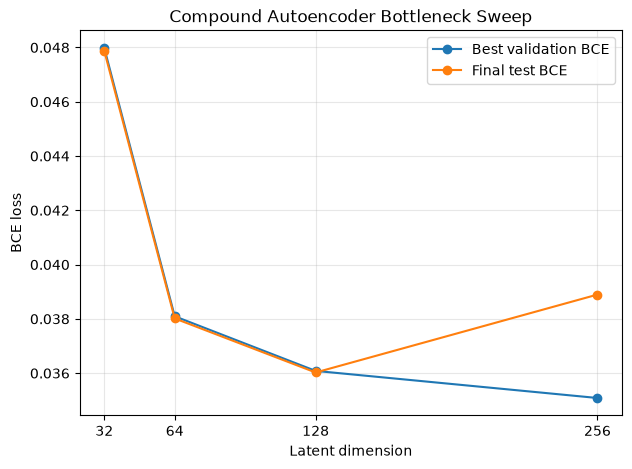

In [25]:
plt.figure(figsize=(7, 5))

plt.plot(summary["latent_dim"], summary["best_val_loss"], marker="o", label="Best validation BCE")
plt.plot(summary["latent_dim"], summary["final_test_loss"], marker="o", label="Final test BCE")

plt.xlabel("Latent dimension")
plt.ylabel("BCE loss")
plt.title("Compound Autoencoder Bottleneck Sweep")
plt.xticks(summary["latent_dim"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_bottleneck_sweep_bce.png", dpi=300, bbox_inches="tight")
plt.show()

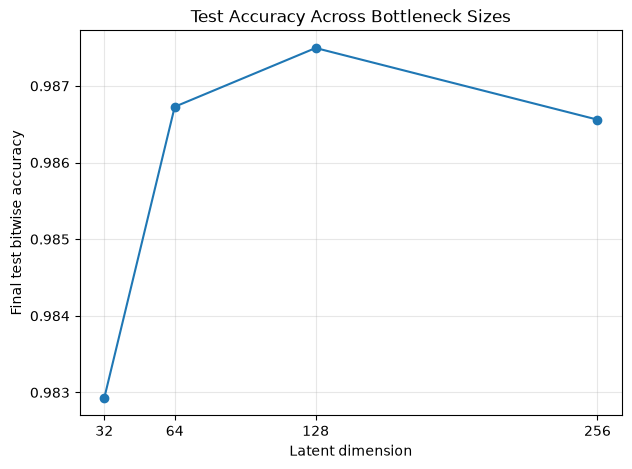

In [26]:
plt.figure(figsize=(7, 5))

plt.plot(
    summary["latent_dim"],
    summary["final_test_bitwise_accuracy"],
    marker="o"
)

plt.xlabel("Latent dimension")
plt.ylabel("Final test bitwise accuracy")
plt.title("Test Accuracy Across Bottleneck Sizes")
plt.xticks(summary["latent_dim"])
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_bottleneck_sweep_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

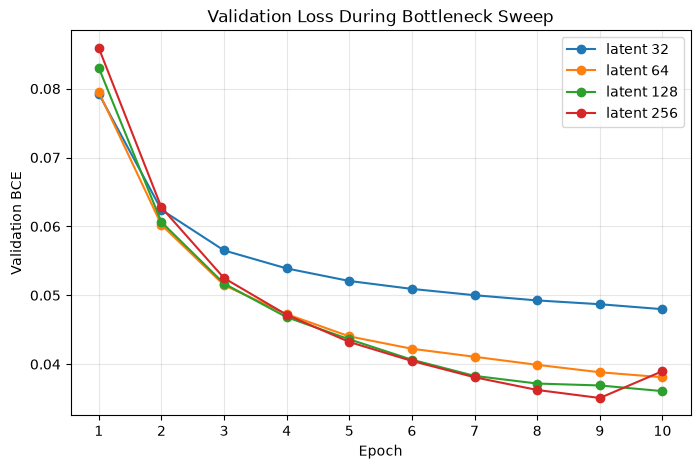

In [27]:
plt.figure(figsize=(8, 5))

for latent_dim in sorted(sweep_df["latent_dim"].unique()):
    temp = sweep_df[sweep_df["latent_dim"] == latent_dim]
    plt.plot(temp["epoch"], temp["val_loss"], marker="o", label=f"latent {latent_dim}")

plt.xlabel("Epoch")
plt.ylabel("Validation BCE")
plt.title("Validation Loss During Bottleneck Sweep")
plt.xticks(range(1, sweep_df["epoch"].max() + 1))
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_bottleneck_sweep_val_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
best_checkpoint_results = []

for latent_dim in SWEEP_LATENT_DIMS:
    print(f"Evaluating best checkpoint for latent_dim={latent_dim}")
    
    checkpoint_path = MODEL_DIR / f"step1_sweep_latent{latent_dim}_best.pt"
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    model = CompoundAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    
    test_loss, test_acc = evaluate_model(model, sweep_test_idx)
    
    best_checkpoint_results.append({
        "latent_dim": latent_dim,
        "best_epoch": checkpoint["epoch"],
        "best_val_loss": checkpoint["best_val_loss"],
        "best_checkpoint_test_loss": test_loss,
        "best_checkpoint_test_accuracy": test_acc
    })

best_checkpoint_summary = pd.DataFrame(best_checkpoint_results)
best_checkpoint_summary

Evaluating best checkpoint for latent_dim=32
Evaluating best checkpoint for latent_dim=64
Evaluating best checkpoint for latent_dim=128
Evaluating best checkpoint for latent_dim=256


,latent_dim,best_epoch,best_val_loss,best_checkpoint_test_loss,best_checkpoint_test_accuracy
0,32,10,0.047981,0.047875,0.982927
1,64,10,0.038095,0.038016,0.986728
2,128,10,0.036083,0.036025,0.987494
3,256,9,0.035085,0.034981,0.987909


In [29]:
best_checkpoint_summary.to_csv(
    MODEL_DIR / "step1_bottleneck_sweep_best_checkpoint_summary.csv",
    index=False
)

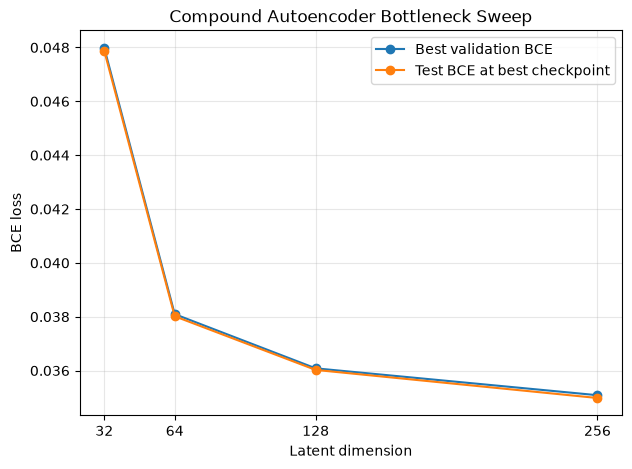

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_val_loss"],
    marker="o",
    label="Best validation BCE"
)

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_checkpoint_test_loss"],
    marker="o",
    label="Test BCE at best checkpoint"
)

plt.xlabel("Latent dimension")
plt.ylabel("BCE loss")
plt.title("Compound Autoencoder Bottleneck Sweep")
plt.xticks(best_checkpoint_summary["latent_dim"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_bottleneck_sweep_best_checkpoint_bce.png", dpi=300, bbox_inches="tight")
plt.show()

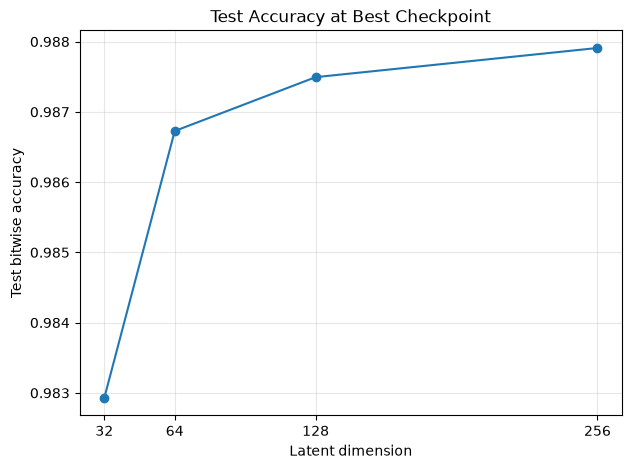

In [31]:
plt.figure(figsize=(7, 5))

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_checkpoint_test_accuracy"],
    marker="o"
)

plt.xlabel("Latent dimension")
plt.ylabel("Test bitwise accuracy")
plt.title("Test Accuracy at Best Checkpoint")
plt.xticks(best_checkpoint_summary["latent_dim"])
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_bottleneck_sweep_best_checkpoint_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

MODEL_DIR = Path("../models")

full_metrics_path = MODEL_DIR / "step1_compound_autoencoder_latent128_metrics.csv"
full_df = pd.read_csv(full_metrics_path)

full_df.head(), full_df.tail()

(   epoch  train_loss  val_loss  val_bitwise_accuracy  elapsed_min  latent_dim  \
 0      1    0.057677  0.037315              0.986998    30.395961         128   
 1      2    0.033370  0.030641              0.989486    28.136499         128   
 2      3    0.029628  0.027472              0.990671    32.472206         128   
 3      4    0.031946  0.027546              0.990686    28.671522         128   
 4      5    0.026725  0.025912              0.991258    32.503233         128   
 
    batch_size     lr  
 0         512  0.001  
 1         512  0.001  
 2         512  0.001  
 3         512  0.001  
 4         512  0.001  ,
     epoch  train_loss  val_loss  val_bitwise_accuracy  elapsed_min  \
 45     46    0.028019  0.028557              0.990243    30.397141   
 46     47    0.028621  0.028770              0.990179    29.238049   
 47     48    0.028090  0.028691              0.990197    28.151498   
 48     49    0.027912  0.028535              0.990249    28.033481   
 49   

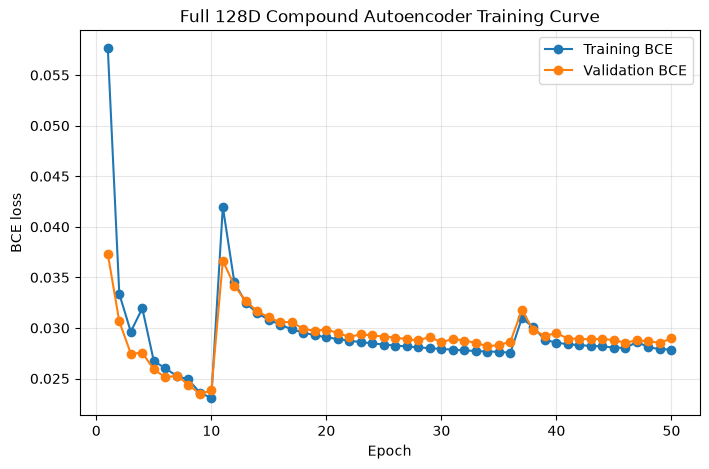

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(full_df["epoch"], full_df["train_loss"], marker="o", label="Training BCE")
plt.plot(full_df["epoch"], full_df["val_loss"], marker="o", label="Validation BCE")

plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Full 128D Compound Autoencoder Training Curve")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_full_128_train_val_bce.png", dpi=300, bbox_inches="tight")
plt.show()

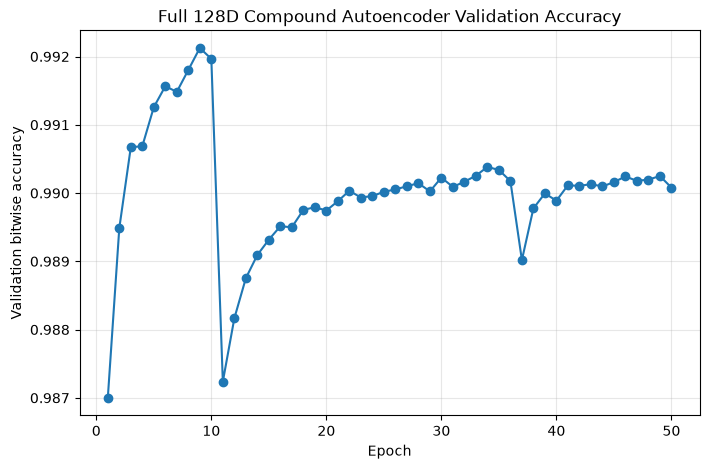

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(full_df["epoch"], full_df["val_bitwise_accuracy"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("Validation bitwise accuracy")
plt.title("Full 128D Compound Autoencoder Validation Accuracy")
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_full_128_val_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

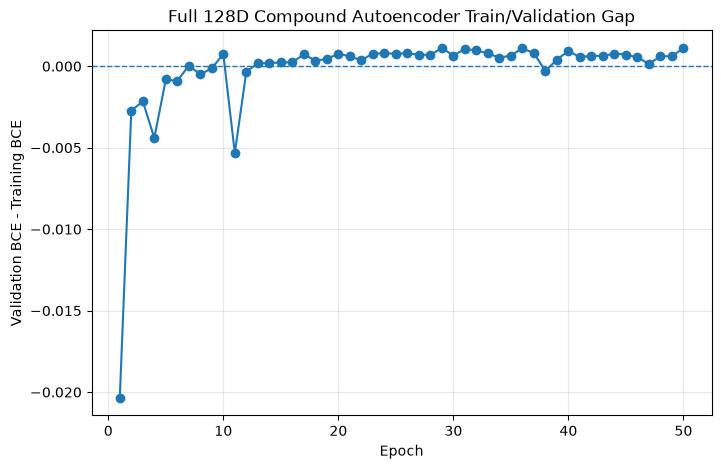

In [35]:
full_df["train_val_gap"] = full_df["val_loss"] - full_df["train_loss"]

plt.figure(figsize=(8, 5))

plt.plot(full_df["epoch"], full_df["train_val_gap"], marker="o")

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Epoch")
plt.ylabel("Validation BCE - Training BCE")
plt.title("Full 128D Compound Autoencoder Train/Validation Gap")
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_full_128_train_val_gap.png", dpi=300, bbox_inches="tight")
plt.show()

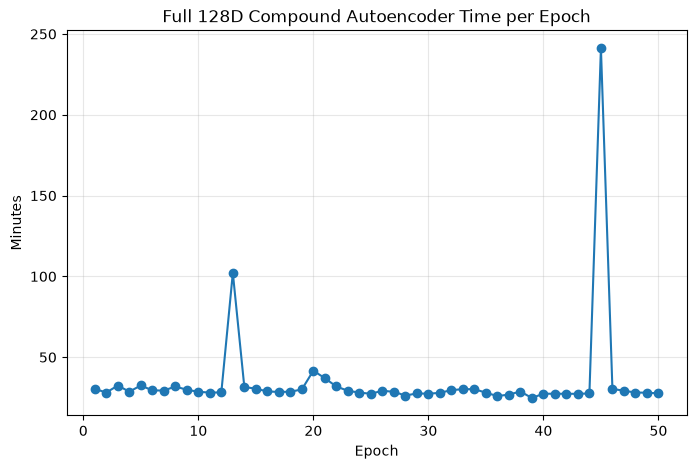

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(full_df["epoch"], full_df["elapsed_min"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("Minutes")
plt.title("Full 128D Compound Autoencoder Time per Epoch")
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_full_128_epoch_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
final_row = full_df.iloc[-1]
best_row = full_df.loc[full_df["val_loss"].idxmin()]

print("Final epoch:", int(final_row["epoch"]))
print("Final train BCE:", final_row["train_loss"])
print("Final val BCE:", final_row["val_loss"])
print("Final val accuracy:", final_row["val_bitwise_accuracy"])

print("\nBest validation epoch:", int(best_row["epoch"]))
print("Best val BCE:", best_row["val_loss"])
print("Best val accuracy:", best_row["val_bitwise_accuracy"])

Final epoch: 50
Final train BCE: 0.0278596479649751
Final val BCE: 0.0289632855188846
Final val accuracy: 0.9900798842151546

Best validation epoch: 9
Best val BCE: 0.0234951256740093
Best val accuracy: 0.9921246416532316


In [38]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

MODEL_DIR = Path("../models")

FIG_DIR = Path("../figures")
BOTTLENECK_FIG_DIR = FIG_DIR / "step1_bottleneck_sweep"
FULL128_FIG_DIR = FIG_DIR / "step1_full_128"

BOTTLENECK_FIG_DIR.mkdir(parents=True, exist_ok=True)
FULL128_FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "figure.titlesize": 22,
})

In [39]:
# Load bottleneck results
best_checkpoint_summary = pd.read_csv(
    MODEL_DIR / "step1_bottleneck_sweep_best_checkpoint_summary.csv"
)

sweep_df = pd.read_csv(
    MODEL_DIR / "step1_bottleneck_sweep_500k_metrics.csv"
)

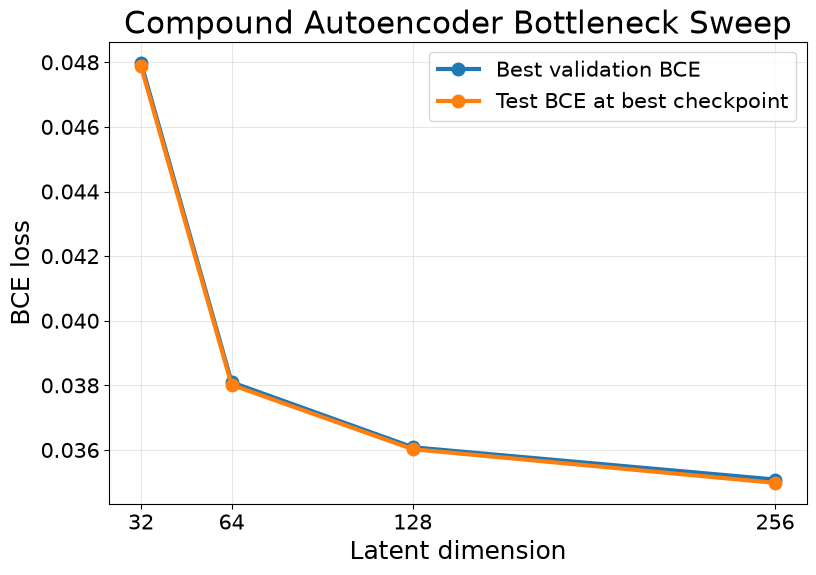

In [40]:
plt.figure(figsize=(9, 6))

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_val_loss"],
    marker="o",
    linewidth=3,
    markersize=9,
    label="Best validation BCE"
)

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_checkpoint_test_loss"],
    marker="o",
    linewidth=3,
    markersize=9,
    label="Test BCE at best checkpoint"
)

plt.xlabel("Latent dimension")
plt.ylabel("BCE loss")
plt.title("Compound Autoencoder Bottleneck Sweep")
plt.xticks(best_checkpoint_summary["latent_dim"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_bce.png", dpi=300, bbox_inches="tight")
plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_bce.pdf", bbox_inches="tight")
plt.show()

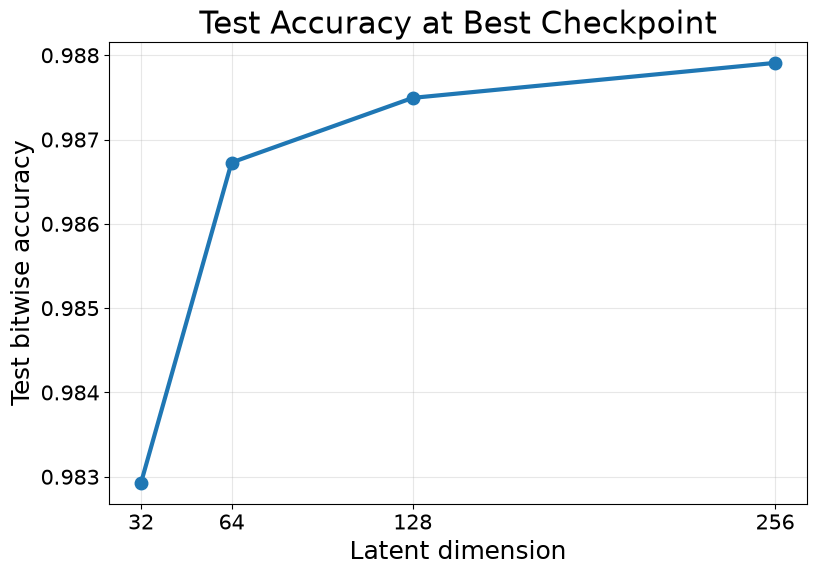

In [41]:
plt.figure(figsize=(9, 6))

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_checkpoint_test_accuracy"],
    marker="o",
    linewidth=3,
    markersize=9
)

plt.xlabel("Latent dimension")
plt.ylabel("Test bitwise accuracy")
plt.title("Test Accuracy at Best Checkpoint")
plt.xticks(best_checkpoint_summary["latent_dim"])
plt.grid(True, alpha=0.3)

plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_test_accuracy.png", dpi=300, bbox_inches="tight")
plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_test_accuracy.pdf", bbox_inches="tight")
plt.show()

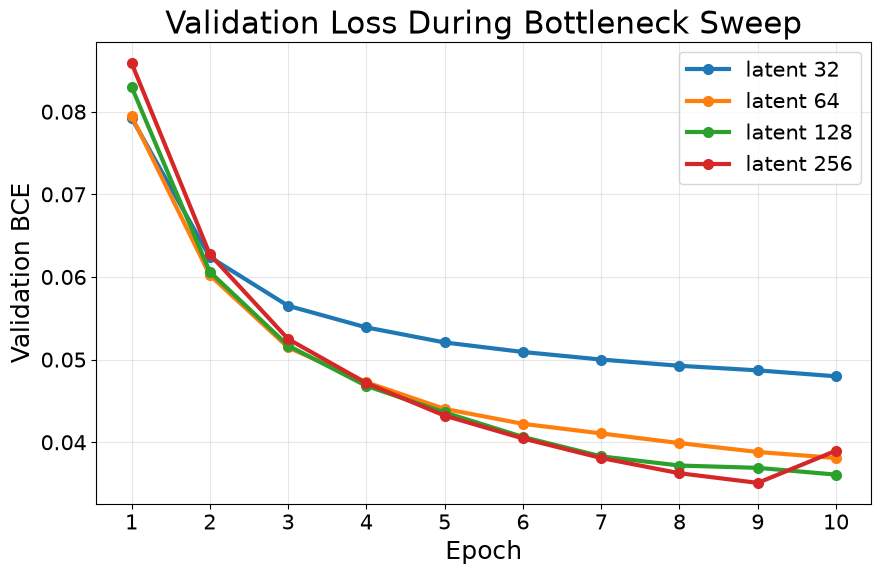

In [42]:
plt.figure(figsize=(10, 6))

for latent_dim in sorted(sweep_df["latent_dim"].unique()):
    temp = sweep_df[sweep_df["latent_dim"] == latent_dim]
    plt.plot(
        temp["epoch"],
        temp["val_loss"],
        marker="o",
        linewidth=3,
        markersize=7,
        label=f"latent {latent_dim}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation BCE")
plt.title("Validation Loss During Bottleneck Sweep")
plt.xticks(range(1, sweep_df["epoch"].max() + 1))
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_validation_curves.png", dpi=300, bbox_inches="tight")
plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_validation_curves.pdf", bbox_inches="tight")
plt.show()

In [43]:
full_df = pd.read_csv(MODEL_DIR / "step1_compound_autoencoder_latent128_metrics.csv")

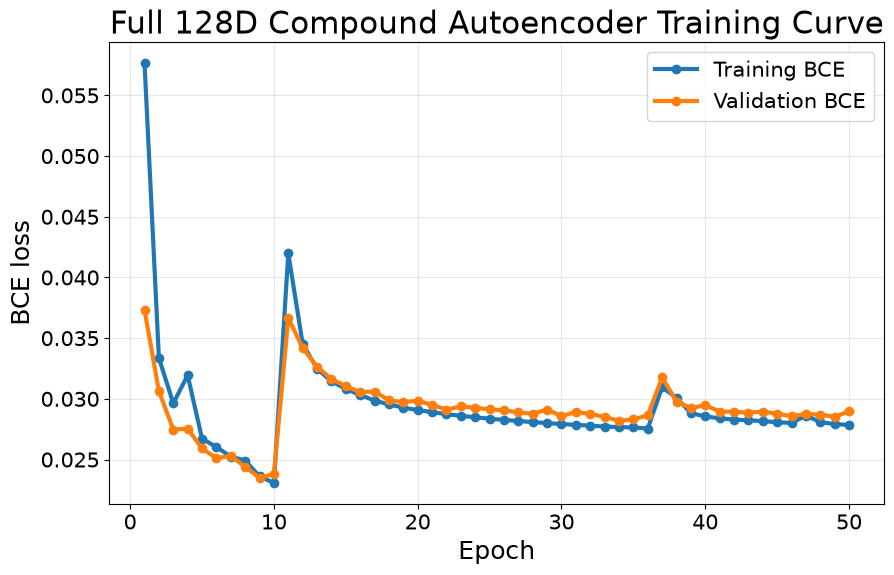

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    full_df["epoch"],
    full_df["train_loss"],
    marker="o",
    linewidth=3,
    markersize=6,
    label="Training BCE"
)

plt.plot(
    full_df["epoch"],
    full_df["val_loss"],
    marker="o",
    linewidth=3,
    markersize=6,
    label="Validation BCE"
)

plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Full 128D Compound Autoencoder Training Curve")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(FULL128_FIG_DIR / "full_128_train_val_bce.png", dpi=300, bbox_inches="tight")
plt.savefig(FULL128_FIG_DIR / "full_128_train_val_bce.pdf", bbox_inches="tight")
plt.show()

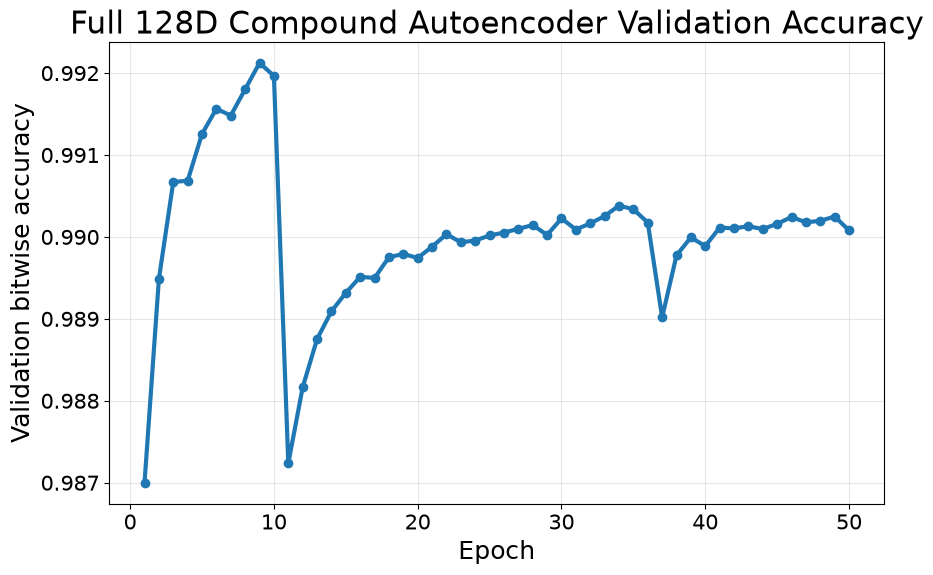

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
    full_df["epoch"],
    full_df["val_bitwise_accuracy"],
    marker="o",
    linewidth=3,
    markersize=6
)

plt.xlabel("Epoch")
plt.ylabel("Validation bitwise accuracy")
plt.title("Full 128D Compound Autoencoder Validation Accuracy")
plt.grid(True, alpha=0.3)

plt.savefig(FULL128_FIG_DIR / "full_128_validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.savefig(FULL128_FIG_DIR / "full_128_validation_accuracy.pdf", bbox_inches="tight")
plt.show()

In [49]:
LATENT_DIM = 128
BATCH_SIZE = 512
SEED = 42

metrics_path = MODEL_DIR / "step1_compound_autoencoder_latent128_metrics.csv"

full_metrics = pd.read_csv(metrics_path)

best_row = full_metrics.loc[full_metrics["val_loss"].idxmin()]
final_row = full_metrics.iloc[-1]

print("Best validation epoch:")
print(best_row)

print("\nFinal epoch:")
print(final_row)

Best validation epoch:
epoch                     9.000000
train_loss                0.023614
val_loss                  0.023495
val_bitwise_accuracy      0.992125
elapsed_min              29.840209
latent_dim              128.000000
batch_size              512.000000
lr                        0.001000
Name: 8, dtype: float64

Final epoch:
epoch                    50.000000
train_loss                0.027860
val_loss                  0.028963
val_bitwise_accuracy      0.990080
elapsed_min              27.640049
latent_dim              128.000000
batch_size              512.000000
lr                        0.001000
Name: 49, dtype: float64


In [48]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from torch import nn
import time

print("Current working directory:", Path.cwd())

# Try to locate project root automatically
cwd = Path.cwd()

if (cwd / "models").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find models folder from current directory or parent.")

DATA_DIR = PROJECT_ROOT / "data"
FP_DIR = DATA_DIR / "step1_fingerprints"
MODEL_DIR = PROJECT_ROOT / "models"
EMB_DIR = DATA_DIR / "step1_embeddings"
EMB_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("FP_DIR:", FP_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("EMB_DIR:", EMB_DIR)

print("\nModel files:")
for f in sorted(MODEL_DIR.glob("step1_compound_autoencoder_latent128*")):
    print(f.name)

Current working directory: /Users/mell/predicting-predictability
PROJECT_ROOT: /Users/mell/predicting-predictability
DATA_DIR: /Users/mell/predicting-predictability/data
FP_DIR: /Users/mell/predicting-predictability/data/step1_fingerprints
MODEL_DIR: /Users/mell/predicting-predictability/models
EMB_DIR: /Users/mell/predicting-predictability/data/step1_embeddings

Model files:
step1_compound_autoencoder_latent128_best.pt
step1_compound_autoencoder_latent128_latest.pt
step1_compound_autoencoder_latent128_metrics.csv
step1_compound_autoencoder_latent128_summary.txt


In [50]:
checkpoint_path = MODEL_DIR / "step1_compound_autoencoder_latent128_best.pt"
print("Checkpoint exists:", checkpoint_path.exists())
print(checkpoint_path)

Checkpoint exists: True
/Users/mell/predicting-predictability/models/step1_compound_autoencoder_latent128_best.pt


In [52]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import torch
from torch import nn
from numpy.lib.format import open_memmap

# Locate project root automatically
cwd = Path.cwd()

if (cwd / "models").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find models folder.")

DATA_DIR = PROJECT_ROOT / "data"
FP_DIR = DATA_DIR / "step1_fingerprints"
MODEL_DIR = PROJECT_ROOT / "models"
EMB_DIR = DATA_DIR / "step1_embeddings"
FIG_DIR = PROJECT_ROOT / "figures" / "step1_embeddings"

EMB_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

LATENT_DIM = 128
BATCH_SIZE = 512
SEED = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FP_DIR:", FP_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("EMB_DIR:", EMB_DIR)
print("FIG_DIR:", FIG_DIR)

PROJECT_ROOT: /Users/mell/predicting-predictability
FP_DIR: /Users/mell/predicting-predictability/data/step1_fingerprints
MODEL_DIR: /Users/mell/predicting-predictability/models
EMB_DIR: /Users/mell/predicting-predictability/data/step1_embeddings
FIG_DIR: /Users/mell/predicting-predictability/figures/step1_embeddings


In [53]:
metrics_path = MODEL_DIR / "step1_compound_autoencoder_latent128_metrics.csv"
full_metrics = pd.read_csv(metrics_path)

best_row = full_metrics.loc[full_metrics["val_loss"].idxmin()]
final_row = full_metrics.iloc[-1]

print("Best validation epoch:")
print(best_row)

print("\nFinal epoch:")
print(final_row)

Best validation epoch:
epoch                     9.000000
train_loss                0.023614
val_loss                  0.023495
val_bitwise_accuracy      0.992125
elapsed_min              29.840209
latent_dim              128.000000
batch_size              512.000000
lr                        0.001000
Name: 8, dtype: float64

Final epoch:
epoch                    50.000000
train_loss                0.027860
val_loss                  0.028963
val_bitwise_accuracy      0.990080
elapsed_min              27.640049
latent_dim              128.000000
batch_size              512.000000
lr                        0.001000
Name: 49, dtype: float64


In [54]:
fingerprint_files = {
    "maccs": FP_DIR / "step1_maccs_packed.npy",
    "morgan": FP_DIR / "step1_morgan_packed.npy",
    "avalon": FP_DIR / "step1_avalon_packed.npy",
    "torsion": FP_DIR / "step1_torsion_packed.npy",
    "pattern": FP_DIR / "step1_pattern_packed.npy",
}

fingerprint_bits = {
    "maccs": 167,
    "morgan": 2048,
    "avalon": 512,
    "torsion": 2048,
    "pattern": 2048,
}

fp_order = ["maccs", "morgan", "avalon", "torsion", "pattern"]

arrays = {
    name: np.load(path, mmap_mode="r")
    for name, path in fingerprint_files.items()
}

n_total = arrays["morgan"].shape[0]
input_dim = sum(fingerprint_bits.values())

print("Total compounds:", n_total)
print("Input dim:", input_dim)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)


def make_batch(batch_indices):
    parts = []

    for name in fp_order:
        packed = arrays[name][batch_indices]
        bits = np.unpackbits(packed, axis=1)[:, :fingerprint_bits[name]]
        parts.append(bits)

    x = np.concatenate(parts, axis=1).astype(np.float32, copy=False)
    return torch.from_numpy(x).to(device)

Total compounds: 3765890
Input dim: 6823
Device: mps


In [55]:
class CompoundAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 2048),
            nn.ReLU(),
            nn.Linear(2048, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        logits = self.decoder(z)
        return logits, z


checkpoint_path = MODEL_DIR / "step1_compound_autoencoder_latent128_best.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

model = CompoundAutoencoder(input_dim=input_dim, latent_dim=LATENT_DIM).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded:", checkpoint_path)
print("Best checkpoint epoch:", checkpoint["epoch"])
print("Best val loss:", checkpoint.get("best_val_loss"))

Loaded: /Users/mell/predicting-predictability/models/step1_compound_autoencoder_latent128_best.pt
Best checkpoint epoch: 9
Best val loss: 0.023495125674009323


In [56]:
split_path = FP_DIR / f"step1_split_80_10_10_seed{SEED}.npz"
split = np.load(split_path)

train_idx = split["train_idx"]
val_idx = split["val_idx"]
test_idx = split["test_idx"]

print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))

criterion = nn.BCEWithLogitsLoss()

def evaluate_model(model, eval_idx, max_rows=100_000):
    model.eval()
    rng = np.random.default_rng(SEED)

    if max_rows is not None and len(eval_idx) > max_rows:
        eval_idx = rng.choice(eval_idx, size=max_rows, replace=False)

    total_loss = 0.0
    total_bits_correct = 0
    total_bits = 0
    total_rows = 0

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_batch(batch_idx)

            logits, _ = model(x)
            loss = criterion(logits, x)

            preds = torch.sigmoid(logits) > 0.5
            truth = x > 0.5

            total_bits_correct += (preds == truth).sum().item()
            total_bits += truth.numel()

            total_loss += loss.item() * len(batch_idx)
            total_rows += len(batch_idx)

    return total_loss / total_rows, total_bits_correct / total_bits


best_test_loss, best_test_acc = evaluate_model(model, test_idx, max_rows=100_000)

print("Best checkpoint test BCE:", best_test_loss)
print("Best checkpoint test bitwise accuracy:", best_test_acc)

Train: 3012712
Val: 376589
Test: 376589
Best checkpoint test BCE: 0.02343893751382828
Best checkpoint test bitwise accuracy: 0.9921464106697934


In [57]:
embedding_path = EMB_DIR / "step1_drug_embeddings_128.npy"
recon_error_path = EMB_DIR / "step1_reconstruction_bce_per_compound.npy"
bit_acc_path = EMB_DIR / "step1_bitwise_accuracy_per_compound.npy"

embeddings = open_memmap(
    embedding_path,
    mode="w+",
    dtype=np.float32,
    shape=(n_total, LATENT_DIM)
)

recon_bce = open_memmap(
    recon_error_path,
    mode="w+",
    dtype=np.float32,
    shape=(n_total,)
)

bitwise_acc = open_memmap(
    bit_acc_path,
    mode="w+",
    dtype=np.float32,
    shape=(n_total,)
)

loss_none = nn.BCEWithLogitsLoss(reduction="none")

start_time = time.time()

model.eval()

with torch.no_grad():
    for start in range(0, n_total, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_total)
        batch_idx = np.arange(start, end)

        x = make_batch(batch_idx)
        logits, z = model(x)

        # Save 128D embeddings
        embeddings[start:end, :] = z.detach().cpu().numpy().astype(np.float32)

        # Save per-compound reconstruction BCE
        per_bit_loss = loss_none(logits, x)
        per_compound_bce = per_bit_loss.mean(dim=1)
        recon_bce[start:end] = per_compound_bce.detach().cpu().numpy().astype(np.float32)

        # Save per-compound bitwise accuracy
        preds = torch.sigmoid(logits) > 0.5
        truth = x > 0.5
        per_compound_acc = (preds == truth).float().mean(dim=1)
        bitwise_acc[start:end] = per_compound_acc.detach().cpu().numpy().astype(np.float32)

        if end % 100_000 == 0 or end == n_total:
            elapsed = time.time() - start_time
            rate = end / elapsed
            remaining_min = (n_total - end) / rate / 60

            print(
                f"Processed {end:,}/{n_total:,} | "
                f"~{remaining_min:.1f} min remaining"
            )

embeddings.flush()
recon_bce.flush()
bitwise_acc.flush()

print("Saved embeddings:", embedding_path)
print("Saved per-compound BCE:", recon_error_path)
print("Saved per-compound bitwise accuracy:", bit_acc_path)

Processed 1,600,000/3,765,890 | ~3.7 min remaining
Processed 3,200,000/3,765,890 | ~0.9 min remaining
Processed 3,765,890/3,765,890 | ~0.0 min remaining
Saved embeddings: /Users/mell/predicting-predictability/data/step1_embeddings/step1_drug_embeddings_128.npy
Saved per-compound BCE: /Users/mell/predicting-predictability/data/step1_embeddings/step1_reconstruction_bce_per_compound.npy
Saved per-compound bitwise accuracy: /Users/mell/predicting-predictability/data/step1_embeddings/step1_bitwise_accuracy_per_compound.npy


In [58]:
metadata_path = FP_DIR / "step1_compound_registry_fingerprinted.csv"
metadata = pd.read_csv(metadata_path, low_memory=False)

metadata["embedding_row_index"] = np.arange(len(metadata))
metadata["compound_embedding_file"] = str(embedding_path)
metadata["reconstruction_bce"] = np.load(recon_error_path, mmap_mode="r")
metadata["bitwise_accuracy"] = np.load(bit_acc_path, mmap_mode="r")

out_metadata_path = EMB_DIR / "step1_compound_embeddings_metadata.csv"
metadata.to_csv(out_metadata_path, index=False)

print("Saved:", out_metadata_path)
print("Rows:", len(metadata))

metadata[["canonical_smiles", "source", "reconstruction_bce", "bitwise_accuracy"]].head()

Saved: /Users/mell/predicting-predictability/data/step1_embeddings/step1_compound_embeddings_metadata.csv
Rows: 3765890


,canonical_smiles,source,reconstruction_bce,bitwise_accuracy
0,BrC1C(Br)C(Br)C(Br)C(Br)C1Br,LINCS_small_molecules; lincs-l1000-cp-drug_met...,0.014738,0.995750
1,Brc1c(Br)c(Br)c2[nH]nnc2c1Br,LINCS_small_molecules; lincs-l1000-cp-drug_met...,0.023505,0.992965
2,Brc1ccc2c(c1)CNCC2,Novartis:DRUG-seq U2OS MoABox Dataset-drug-seq...,0.003254,0.999121
3,Brc1cccc(-c2c[nH]nn2)c1,Novartis:DRUG-seq U2OS MoABox Dataset-drug-seq...,0.005830,0.998828
4,C#CC1(O)CCC2C3CCc4cc(OC5CCCC5)ccc4C3CCC21C,Tahoe_100M; tahoe-100m-drug_metadata,0.016563,0.995896


In [59]:
summary = {
    "n_compounds": n_total,
    "latent_dim": LATENT_DIM,
    "checkpoint_epoch": checkpoint["epoch"],
    "best_val_bce": checkpoint.get("best_val_loss"),
    "best_checkpoint_test_bce": best_test_loss,
    "best_checkpoint_test_bitwise_accuracy": best_test_acc,
    "mean_reconstruction_bce": float(metadata["reconstruction_bce"].mean()),
    "median_reconstruction_bce": float(metadata["reconstruction_bce"].median()),
    "mean_bitwise_accuracy": float(metadata["bitwise_accuracy"].mean()),
    "median_bitwise_accuracy": float(metadata["bitwise_accuracy"].median()),
}

summary_df = pd.DataFrame([summary])
summary_path = EMB_DIR / "step1_embedding_extraction_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
summary_df

Saved: /Users/mell/predicting-predictability/data/step1_embeddings/step1_embedding_extraction_summary.csv


,n_compounds,latent_dim,checkpoint_epoch,best_val_bce,best_checkpoint_test_bce,best_checkpoint_test_bitwise_accuracy,mean_reconstruction_bce,median_reconstruction_bce,mean_bitwise_accuracy,median_bitwise_accuracy
0,3765890,128,9,0.023495,0.023439,0.992146,0.023148,0.019421,0.992223,0.993551


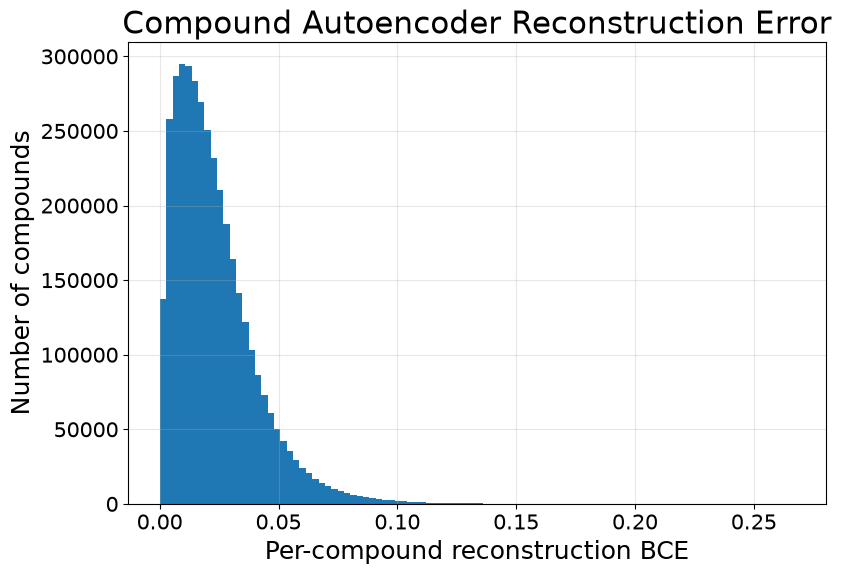

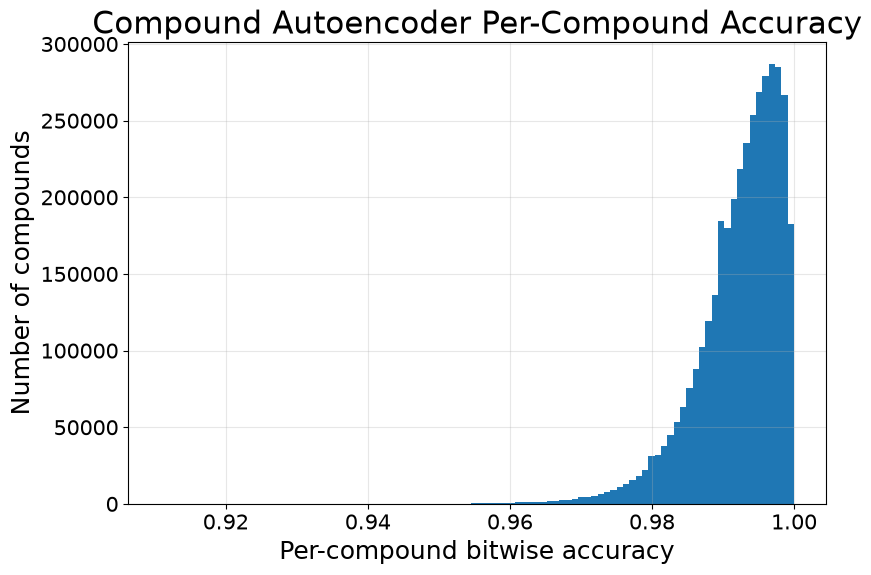

In [60]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
})

# Histogram of reconstruction BCE
plt.figure(figsize=(9, 6))
plt.hist(metadata["reconstruction_bce"], bins=100)
plt.xlabel("Per-compound reconstruction BCE")
plt.ylabel("Number of compounds")
plt.title("Compound Autoencoder Reconstruction Error")
plt.grid(True, alpha=0.3)

plt.savefig(FIG_DIR / "step1_reconstruction_bce_histogram.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "step1_reconstruction_bce_histogram.pdf", bbox_inches="tight")
plt.show()


# Histogram of bitwise accuracy
plt.figure(figsize=(9, 6))
plt.hist(metadata["bitwise_accuracy"], bins=100)
plt.xlabel("Per-compound bitwise accuracy")
plt.ylabel("Number of compounds")
plt.title("Compound Autoencoder Per-Compound Accuracy")
plt.grid(True, alpha=0.3)

plt.savefig(FIG_DIR / "step1_bitwise_accuracy_histogram.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "step1_bitwise_accuracy_histogram.pdf", bbox_inches="tight")
plt.show()

In [1]:
from pathlib import Path
import gzip
import pandas as pd
import numpy as np
import re
import time

# Locate project root automatically
cwd = Path.cwd()

if (cwd / "models").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find project root.")

DATA_DIR = PROJECT_ROOT / "data"
STEP2_RAW_DIR = DATA_DIR / "Step 2 Files"
STEP2_OUT_DIR = DATA_DIR / "step2_signatures"
STEP2_OUT_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STEP2_RAW_DIR:", STEP2_RAW_DIR)
print("STEP2_OUT_DIR:", STEP2_OUT_DIR)

files = sorted(STEP2_RAW_DIR.glob("*.gmt.gz"))
print("GMT files found:", len(files))

for f in files:
    print(f.name)

PROJECT_ROOT: /Users/mell/predicting-predictability
STEP2_RAW_DIR: /Users/mell/predicting-predictability/data/Step 2 Files
STEP2_OUT_DIR: /Users/mell/predicting-predictability/data/step2_signatures
GMT files found: 8
L1000-gmatrix.gmt.gz
cmap-build02-gmatrix.gmt.gz
creeds-gmatrix.gmt.gz
deepcovermoa-gmatrix.gmt.gz
novartis-gmatrix.gmt.gz
rummageo-gmatrix.gmt.gz
sciplex-gmatrix.gmt.gz
tahoe-100m-gmatrix.gmt.gz


In [2]:
for path in files:
    print("\n" + "="*100)
    print(path.name)
    
    with gzip.open(path, "rt", errors="replace") as f:
        for i in range(2):
            line = f.readline().rstrip("\n")
            parts = line.split("\t")
            
            print(f"\nLine {i+1}")
            print("Number of fields:", len(parts))
            print("First field / signature term:", parts[0][:300])
            print("Second field / description:", parts[1][:200] if len(parts) > 1 else None)
            print("First 10 gene entries:", parts[2:12])


L1000-gmatrix.gmt.gz

Line 1
Number of fields: 252
First field / signature term: bortezomib::HT29::::24H::20uM::REP.B007::C23::BRD-K50691590 up
Second field / description: BRD-K50691590
First 10 gene entries: ['PHOX2B', 'CD55', 'RRBP1', 'CMAS', 'GAB2', 'PPP1R17', 'PLEKHA5', 'KCNMB1', 'SLIT2', 'COCH']

Line 2
Number of fields: 250
First field / signature term: LY-2835219::HAP1.CDK4::::24H::3.33uM::MOAR017::F03::BRD-K33622447 up
Second field / description: BRD-K33622447
First 10 gene entries: ['MGLL', 'ATP6V1H', 'KDELR1', 'IFIT3', 'CISH', 'ERGIC3', 'ZIC1', 'TFDP1', 'TES', 'PMEL']

cmap-build02-gmatrix.gmt.gz

Line 1
Number of fields: 97
First field / signature term: 1,4-chrysenequinone::HL60::::6h::15.4uM::batch641 up
Second field / description: NA
First 10 gene entries: ['ABHD3', 'ADAM8', 'ADCYAP1', 'ALDOB', 'APBA2', 'ARHGAP33', 'ARL4C', 'ATXN1', 'BAG3', 'BIN1']

Line 2
Number of fields: 101
First field / signature term: 1,4-chrysenequinone::HL60::::6h::15.4uM::batch641 down
Second fie

In [3]:
inventory = []

for path in files:
    n_lines = 0
    min_fields = None
    max_fields = 0
    total_gene_entries = 0
    example_term = None
    
    start = time.time()
    
    with gzip.open(path, "rt", errors="replace") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            n_fields = len(parts)
            
            if example_term is None and len(parts) > 0:
                example_term = parts[0]
            
            min_fields = n_fields if min_fields is None else min(min_fields, n_fields)
            max_fields = max(max_fields, n_fields)
            total_gene_entries += max(0, n_fields - 2)
            n_lines += 1
    
    inventory.append({
        "file": path.name,
        "rows": n_lines,
        "min_fields": min_fields,
        "max_fields": max_fields,
        "total_gene_entries": total_gene_entries,
        "mean_genes_per_row": total_gene_entries / n_lines if n_lines else np.nan,
        "example_term": example_term,
        "elapsed_sec": time.time() - start
    })

inventory_df = pd.DataFrame(inventory)
inventory_df.to_csv(STEP2_OUT_DIR / "step2_gmt_file_inventory.csv", index=False)

inventory_df

,file,rows,min_fields,max_fields,total_gene_entries,mean_genes_per_row,example_term,elapsed_sec
0,L1000-gmatrix.gmt.gz,156926,240,252,38786679,247.165409,bortezomib::HT29::::24H::20uM::REP.B007::C23::...,2.196861
1,cmap-build02-gmatrix.gmt.gz,11994,86,102,1143521,95.341087,"1,4-chrysenequinone::HL60::::6h::15.4uM::batch...",0.073922
2,creeds-gmatrix.gmt.gz,1542,3,5914,438873,284.612840,Fluorouracil::::::::::mus musculus::GSE1559.36...,0.027453
3,deepcovermoa-gmatrix.gmt.gz,1748,94,102,172420,98.638444,(4-Chlorobenzyl)pyridine::HCT116::::24h::10uM up,0.012788
4,novartis-gmatrix.gmt.gz,18810,5,7884,2361911,125.566773,"2-amino-7-(thiophen-3-ylmethyl)-1,5-dihydropyr...",0.138583
5,rummageo-gmatrix.gmt.gz,5345,6,1919,3997947,747.978859,ethanol::::::::::mouse::GSE100217::1::0 up,0.208986
6,sciplex-gmatrix.gmt.gz,4604,495,502,2295151,498.512381,2-Methoxyestradiol::A549::::24h::100nM up,0.121982
7,tahoe-100m-gmatrix.gmt.gz,105404,6,102,9732516,92.335357,(R)-Verapamil (hydrochloride)::A-172::CNS/Brai...,0.622132


In [4]:
from scipy import sparse

def parse_direction_and_base(term):
    term = str(term).strip()
    lower = term.lower()
    
    if lower.endswith(" up"):
        return term[:-3].strip(), "up", 1
    elif lower.endswith(" down"):
        return term[:-5].strip(), "down", -1
    else:
        return term, "unknown", 1


gene_to_col = {}
sig_to_row = {}

rows = []
cols = []
vals = []

metadata_records = []

start_time = time.time()

for path in files:
    source = path.name.replace("-gmatrix.gmt.gz", "").replace(".gmt.gz", "")
    print("\nParsing:", path.name)
    
    file_line_count = 0
    
    with gzip.open(path, "rt", errors="replace") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            
            if len(parts) < 3:
                continue
            
            term = parts[0]
            desc = parts[1]
            genes = [g.strip() for g in parts[2:] if g.strip()]
            
            base_term, direction, sign = parse_direction_and_base(term)
            
            # Add source to avoid accidental collisions across datasets
            signature_id = f"{source}::{base_term}"
            
            if signature_id not in sig_to_row:
                sig_to_row[signature_id] = len(sig_to_row)
                metadata_records.append({
                    "signature_id": signature_id,
                    "source": source,
                    "source_file": path.name,
                    "base_term": base_term,
                    "description": desc,
                })
            
            row_id = sig_to_row[signature_id]
            
            for gene in genes:
                if gene not in gene_to_col:
                    gene_to_col[gene] = len(gene_to_col)
                
                col_id = gene_to_col[gene]
                
                rows.append(row_id)
                cols.append(col_id)
                vals.append(sign)
            
            file_line_count += 1
            
            if file_line_count % 50_000 == 0:
                elapsed = time.time() - start_time
                print(
                    f"  {file_line_count:,} rows from this file | "
                    f"{len(sig_to_row):,} signatures | "
                    f"{len(gene_to_col):,} genes | "
                    f"{elapsed/60:.1f} min elapsed"
                )

print("\nBuilding sparse matrix...")

X = sparse.coo_matrix(
    (np.array(vals, dtype=np.int8), (np.array(rows), np.array(cols))),
    shape=(len(sig_to_row), len(gene_to_col)),
    dtype=np.int8
).tocsr()

# If duplicate gene entries appear, sum them, then clip to -1/0/1
X.sum_duplicates()
X.data = np.clip(X.data, -1, 1).astype(np.int8)

signature_metadata = pd.DataFrame(metadata_records)

gene_index = (
    pd.DataFrame({
        "gene": list(gene_to_col.keys()),
        "gene_col": list(gene_to_col.values())
    })
    .sort_values("gene_col")
    .reset_index(drop=True)
)

print("Matrix shape:", X.shape)
print("Nonzero entries:", X.nnz)
print("Density:", X.nnz / (X.shape[0] * X.shape[1]))

signature_metadata.head()


Parsing: L1000-gmatrix.gmt.gz
  50,000 rows from this file | 50,000 signatures | 10,284 genes | 0.0 min elapsed
  100,000 rows from this file | 78,463 signatures | 10,465 genes | 0.1 min elapsed
  150,000 rows from this file | 78,463 signatures | 10,546 genes | 0.1 min elapsed

Parsing: cmap-build02-gmatrix.gmt.gz

Parsing: creeds-gmatrix.gmt.gz

Parsing: deepcovermoa-gmatrix.gmt.gz

Parsing: novartis-gmatrix.gmt.gz

Parsing: rummageo-gmatrix.gmt.gz

Parsing: sciplex-gmatrix.gmt.gz

Parsing: tahoe-100m-gmatrix.gmt.gz
  50,000 rows from this file | 152,695 signatures | 20,918 genes | 0.2 min elapsed
  100,000 rows from this file | 155,690 signatures | 20,919 genes | 0.2 min elapsed

Building sparse matrix...
Matrix shape: (155722, 20919)
Nonzero entries: 58928691
Density: 0.018089888968462635


,signature_id,source,source_file,base_term,description
0,L1000::bortezomib::HT29::::24H::20uM::REP.B007...,L1000,L1000-gmatrix.gmt.gz,bortezomib::HT29::::24H::20uM::REP.B007::C23::...,BRD-K50691590
1,L1000::LY-2835219::HAP1.CDK4::::24H::3.33uM::M...,L1000,L1000-gmatrix.gmt.gz,LY-2835219::HAP1.CDK4::::24H::3.33uM::MOAR017:...,BRD-K33622447
2,L1000::torin-1::HAP1.CDK4::::24H::3.33uM::MOAR...,L1000,L1000-gmatrix.gmt.gz,torin-1::HAP1.CDK4::::24H::3.33uM::MOAR017::L0...,BRD-K40175214
3,L1000::dequalinium::HAP1.CDK4::::24H::0.66uM::...,L1000,L1000-gmatrix.gmt.gz,dequalinium::HAP1.CDK4::::24H::0.66uM::MOAR017...,BRD-K77685957
4,L1000::PD-0325901::HAP1.CDK4::::24H::3.33uM::M...,L1000,L1000-gmatrix.gmt.gz,PD-0325901::HAP1.CDK4::::24H::3.33uM::MOAR017:...,BRD-K49865102


In [5]:
from scipy import sparse

matrix_path = STEP2_OUT_DIR / "step2_signature_gene_matrix_signed_sparse.npz"
metadata_path = STEP2_OUT_DIR / "step2_signature_metadata.csv"
gene_index_path = STEP2_OUT_DIR / "step2_gene_index.csv"

sparse.save_npz(matrix_path, X)
signature_metadata.to_csv(metadata_path, index=False)
gene_index.to_csv(gene_index_path, index=False)

print("Saved matrix:", matrix_path)
print("Saved metadata:", metadata_path)
print("Saved gene index:", gene_index_path)

print("Signatures:", X.shape[0])
print("Genes:", X.shape[1])
print("Nonzero entries:", X.nnz)

Saved matrix: /Users/mell/predicting-predictability/data/step2_signatures/step2_signature_gene_matrix_signed_sparse.npz
Saved metadata: /Users/mell/predicting-predictability/data/step2_signatures/step2_signature_metadata.csv
Saved gene index: /Users/mell/predicting-predictability/data/step2_signatures/step2_gene_index.csv
Signatures: 155722
Genes: 20919
Nonzero entries: 58928691


In [6]:
print("Signature metadata:")
display(signature_metadata.head())

print("Gene index:")
display(gene_index.head())

nonzeros_per_signature = np.diff(X.indptr)

print("Genes per signature summary:")
pd.Series(nonzeros_per_signature).describe()

Signature metadata:


,signature_id,source,source_file,base_term,description
0,L1000::bortezomib::HT29::::24H::20uM::REP.B007...,L1000,L1000-gmatrix.gmt.gz,bortezomib::HT29::::24H::20uM::REP.B007::C23::...,BRD-K50691590
1,L1000::LY-2835219::HAP1.CDK4::::24H::3.33uM::M...,L1000,L1000-gmatrix.gmt.gz,LY-2835219::HAP1.CDK4::::24H::3.33uM::MOAR017:...,BRD-K33622447
2,L1000::torin-1::HAP1.CDK4::::24H::3.33uM::MOAR...,L1000,L1000-gmatrix.gmt.gz,torin-1::HAP1.CDK4::::24H::3.33uM::MOAR017::L0...,BRD-K40175214
3,L1000::dequalinium::HAP1.CDK4::::24H::0.66uM::...,L1000,L1000-gmatrix.gmt.gz,dequalinium::HAP1.CDK4::::24H::0.66uM::MOAR017...,BRD-K77685957
4,L1000::PD-0325901::HAP1.CDK4::::24H::3.33uM::M...,L1000,L1000-gmatrix.gmt.gz,PD-0325901::HAP1.CDK4::::24H::3.33uM::MOAR017:...,BRD-K49865102


Gene index:


,gene,gene_col
0,PHOX2B,0
1,CD55,1
2,RRBP1,2
3,CMAS,3
4,GAB2,4


Genes per signature summary:


count    155722.000000
mean        378.422387
std         307.644276
min           3.000000
25%         199.000000
50%         491.000000
75%         495.000000
max        9989.000000
dtype: float64

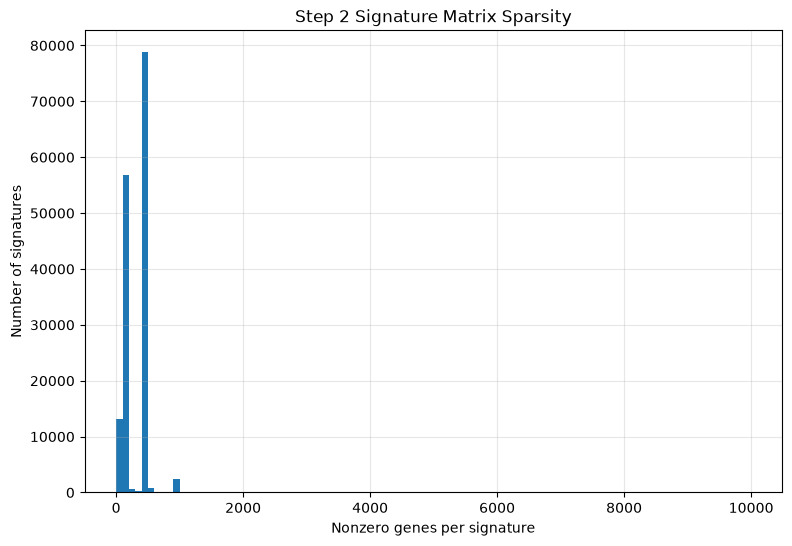

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.hist(nonzeros_per_signature, bins=100)

plt.xlabel("Nonzero genes per signature")
plt.ylabel("Number of signatures")
plt.title("Step 2 Signature Matrix Sparsity")
plt.grid(True, alpha=0.3)

FIG_DIR = PROJECT_ROOT / "figures" / "step2_signatures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(FIG_DIR / "step2_nonzero_genes_per_signature.png", dpi=300, bbox_inches="tight")
plt.show()

In [1]:
# Full Step 2 resume cell: reload everything and train signature autoencoder to epoch 50

from pathlib import Path
import time
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy import sparse


# 1. Paths

cwd = Path.cwd()

if (cwd / "models").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find project root.")

DATA_DIR = PROJECT_ROOT / "data"
STEP2_DIR = DATA_DIR / "step2_signatures"
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "step2_signature_autoencoder"

MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

matrix_path = STEP2_DIR / "step2_signature_gene_matrix_signed_sparse.npz"
split_path = STEP2_DIR / "step2_signature_split_80_10_10_seed42.npz"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODEL_DIR:", MODEL_DIR)


# 2. Load signature matrix

X = sparse.load_npz(matrix_path).tocsr()

print("X shape:", X.shape)
print("Nonzero entries:", X.nnz)


# 3. Load split

SEED = 42
rng = np.random.default_rng(SEED)

if split_path.exists():
    split = np.load(split_path)
    train_idx = split["train_idx"]
    val_idx = split["val_idx"]
    test_idx = split["test_idx"]
else:
    n_total = X.shape[0]
    indices = np.arange(n_total)
    rng.shuffle(indices)

    n_train = int(0.80 * n_total)
    n_val = int(0.10 * n_total)

    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train+n_val]
    test_idx = indices[n_train+n_val:]

    np.savez(
        split_path,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
    )

print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))


# 4. Device/settings

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

INPUT_DIM = X.shape[1]
LATENT_DIM = 128
BATCH_SIZE = 128
EPOCHS = 50

def make_signature_batch(batch_indices):
    batch = X[batch_indices].toarray().astype(np.float32)
    return torch.from_numpy(batch).to(device)


# 5. Model class

class SignatureAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


# 6. Loss/eval functions

def signed_signature_loss(recon, x, zero_weight=0.1):
    mse = (recon - x) ** 2
    nonzero_mask = x != 0
    zero_mask = x == 0

    nonzero_loss = mse[nonzero_mask].mean() if nonzero_mask.any() else torch.tensor(0.0, device=x.device)
    zero_loss = mse[zero_mask].mean() if zero_mask.any() else torch.tensor(0.0, device=x.device)

    return nonzero_loss + zero_weight * zero_loss


def evaluate_signature_model(model, eval_idx, max_rows=20_000):
    model.eval()
    rng_eval = np.random.default_rng(SEED)

    if max_rows is not None and len(eval_idx) > max_rows:
        eval_idx = rng_eval.choice(eval_idx, size=max_rows, replace=False)

    total_loss = 0.0
    total_rows = 0

    total_nonzero_mse = 0.0
    total_zero_mse = 0.0
    total_nonzero_count = 0
    total_zero_count = 0

    total_sign_correct = 0
    total_sign_count = 0

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_signature_batch(batch_idx)

            recon, _ = model(x)
            loss = signed_signature_loss(recon, x)

            total_loss += loss.item() * len(batch_idx)
            total_rows += len(batch_idx)

            mse = (recon - x) ** 2
            nonzero_mask = x != 0
            zero_mask = x == 0

            if nonzero_mask.any():
                total_nonzero_mse += mse[nonzero_mask].sum().item()
                total_nonzero_count += nonzero_mask.sum().item()

                pred_sign = torch.sign(recon[nonzero_mask])
                true_sign = torch.sign(x[nonzero_mask])

                total_sign_correct += (pred_sign == true_sign).sum().item()
                total_sign_count += true_sign.numel()

            if zero_mask.any():
                total_zero_mse += mse[zero_mask].sum().item()
                total_zero_count += zero_mask.sum().item()

    return {
        "loss": total_loss / total_rows,
        "nonzero_mse": total_nonzero_mse / total_nonzero_count,
        "zero_mse": total_zero_mse / total_zero_count,
        "nonzero_sign_accuracy": total_sign_correct / total_sign_count,
    }


# 7. Load latest checkpoint

checkpoint_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_latest.pt"
metrics_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_metrics.csv"

print("Loading latest checkpoint:", checkpoint_path)

checkpoint = torch.load(checkpoint_path, map_location="cpu")

model = SignatureAutoencoder(INPUT_DIM, LATENT_DIM)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

LR = checkpoint.get("lr", 3e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

metrics_df = pd.read_csv(metrics_path)
metrics_df = (
    metrics_df
    .sort_values("epoch")
    .drop_duplicates(subset=["epoch"], keep="last")
    .reset_index(drop=True)
)

metrics = metrics_df.to_dict("records")
best_val_loss = metrics_df["val_loss"].min()

start_epoch = int(checkpoint["epoch"]) + 1

print("Loaded latest checkpoint from epoch:", checkpoint["epoch"])
print("Resuming from epoch:", start_epoch)
print("Training until epoch:", EPOCHS)
print("Best val loss so far:", best_val_loss)
print("LR:", LR)


# 8. Train to epoch 50

for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start = time.time()
    model.train()

    rng.shuffle(train_idx)

    train_loss_sum = 0.0
    train_rows = 0

    for batch_num, start in enumerate(range(0, len(train_idx), BATCH_SIZE), start=1):
        batch_idx = train_idx[start:start+BATCH_SIZE]
        x = make_signature_batch(batch_idx)

        optimizer.zero_grad(set_to_none=True)

        recon, _ = model(x)
        loss = signed_signature_loss(recon, x)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * len(batch_idx)
        train_rows += len(batch_idx)

        if batch_num % 250 == 0:
            print(
                f"Epoch {epoch:02d} | batch {batch_num:,} | "
                f"train loss so far: {train_loss_sum / train_rows:.6f}"
            )

    train_loss = train_loss_sum / train_rows

    val_metrics = evaluate_signature_model(
        model,
        val_idx,
        max_rows=20_000
    )

    elapsed_min = (time.time() - epoch_start) / 60

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_nonzero_mse": val_metrics["nonzero_mse"],
        "val_zero_mse": val_metrics["zero_mse"],
        "val_nonzero_sign_accuracy": val_metrics["nonzero_sign_accuracy"],
        "elapsed_min": elapsed_min,
        "latent_dim": LATENT_DIM,
        "batch_size": BATCH_SIZE,
        "lr": LR,
    }

    metrics.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.6f} | "
        f"val loss: {val_metrics['loss']:.6f} | "
        f"nonzero MSE: {val_metrics['nonzero_mse']:.6f} | "
        f"zero MSE: {val_metrics['zero_mse']:.6f} | "
        f"sign acc: {val_metrics['nonzero_sign_accuracy']:.4f} | "
        f"time: {elapsed_min:.1f} min"
    )

    latest_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_latest.pt"

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "input_dim": INPUT_DIM,
        "latent_dim": LATENT_DIM,
        "loss": "nonzero_mse_plus_0.1_zero_mse",
        "seed": SEED,
        "lr": LR,
        "best_val_loss": best_val_loss,
    }, latest_path)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]

        best_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_best.pt"

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "input_dim": INPUT_DIM,
            "latent_dim": LATENT_DIM,
            "loss": "nonzero_mse_plus_0.1_zero_mse",
            "seed": SEED,
            "lr": LR,
            "best_val_loss": best_val_loss,
        }, best_path)

        print("Saved new best model:", best_path)

    metrics_df = pd.DataFrame(metrics)
    metrics_df = (
        metrics_df
        .sort_values("epoch")
        .drop_duplicates(subset=["epoch"], keep="last")
        .reset_index(drop=True)
    )

    metrics_df.to_csv(metrics_path, index=False)

    print("Saved latest checkpoint + metrics.")

print("Training complete.")
print("Best validation loss:", best_val_loss)

PROJECT_ROOT: /Users/mell/predicting-predictability
MODEL_DIR: /Users/mell/predicting-predictability/models
X shape: (155722, 20919)
Nonzero entries: 58928691
Train: 124577
Val: 15572
Test: 15573
Device: mps
Loading latest checkpoint: /Users/mell/predicting-predictability/models/step2_signature_autoencoder_latent128_latest.pt
Loaded latest checkpoint from epoch: 27
Resuming from epoch: 28
Training until epoch: 50
Best val loss so far: 0.2861289122770355
LR: 0.0003
Epoch 28 | batch 250 | train loss so far: 0.159169
Epoch 28 | batch 500 | train loss so far: 0.160712
Epoch 28 | batch 750 | train loss so far: 0.162066
Epoch 28/50 | train loss: 0.163031 | val loss: 0.292536 | nonzero MSE: 0.276774 | zero MSE: 0.161823 | sign acc: 0.9383 | time: 2.6 min
Saved latest checkpoint + metrics.
Epoch 29 | batch 250 | train loss so far: 0.157809
Epoch 29 | batch 500 | train loss so far: 0.159353
Epoch 29 | batch 750 | train loss so far: 0.160354
Epoch 29/50 | train loss: 0.161163 | val loss: 0.29259

In [2]:
# Evaluate best Step 2 signature autoencoder on test set

best_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_best.pt"
checkpoint = torch.load(best_path, map_location="cpu")

model = SignatureAutoencoder(INPUT_DIM, LATENT_DIM)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Loaded best checkpoint from epoch:", checkpoint["epoch"])
print("Best val loss:", checkpoint.get("best_val_loss"))

test_metrics = evaluate_signature_model(model, test_idx, max_rows=None)

print("Final test metrics:")
for k, v in test_metrics.items():
    print(k, ":", v)

summary_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_summary.txt"

with open(summary_path, "w") as f:
    f.write(f"Step 2 Signature Autoencoder\n")
    f.write(f"Latent dim: {LATENT_DIM}\n")
    f.write(f"Input dim genes: {INPUT_DIM}\n")
    f.write(f"Best checkpoint epoch: {checkpoint['epoch']}\n")
    f.write(f"Best validation loss: {checkpoint.get('best_val_loss')}\n")
    for k, v in test_metrics.items():
        f.write(f"Test {k}: {v}\n")

print("Saved summary:", summary_path)

Loaded best checkpoint from epoch: 18
Best val loss: 0.2861289122770355
Final test metrics:
loss : 0.28964391823817115
nonzero_mse : 0.27435902722247224
zero_mse : 0.15972867097097865
nonzero_sign_accuracy : 0.9374453954741557
Saved summary: /Users/mell/predicting-predictability/models/step2_signature_autoencoder_latent128_summary.txt


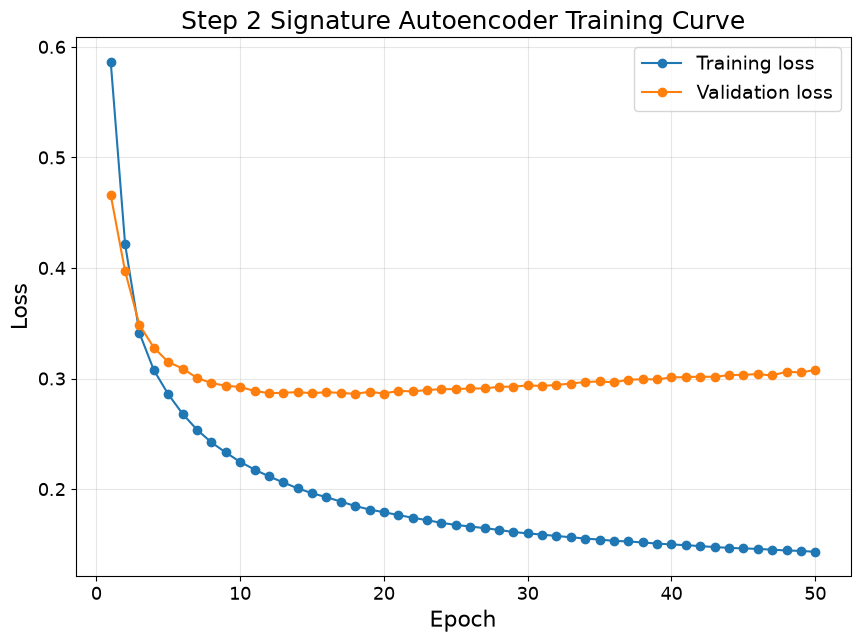

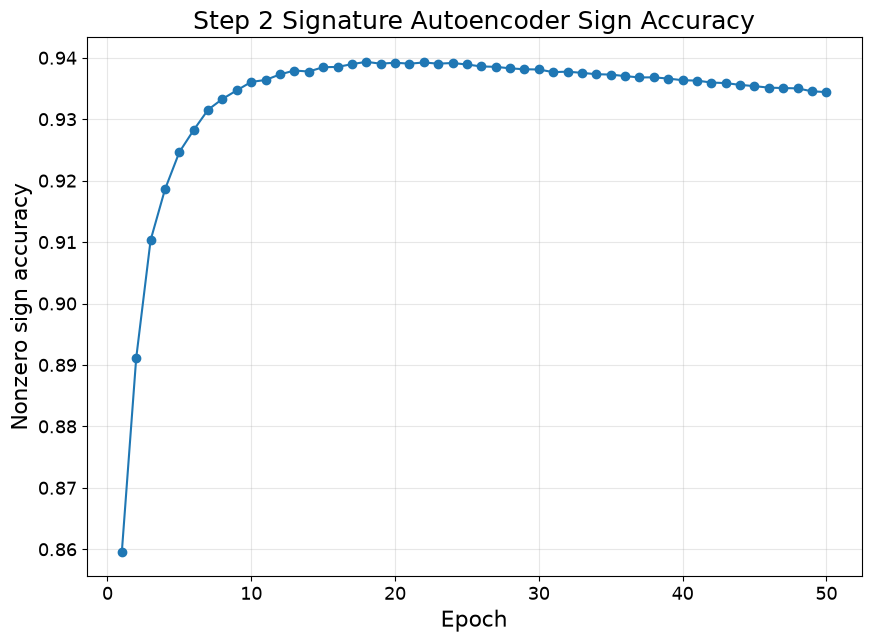

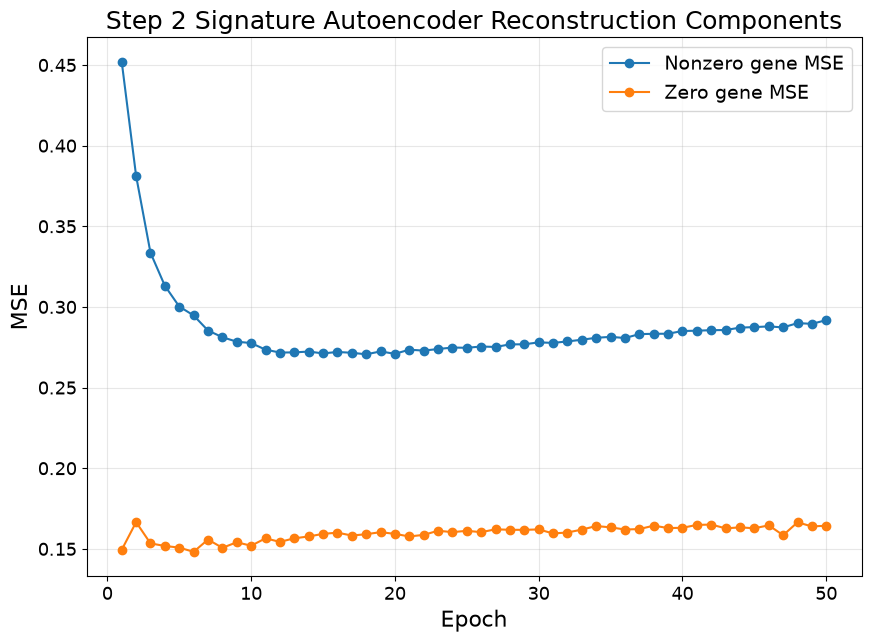

In [3]:
import matplotlib.pyplot as plt

metrics_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_metrics.csv"
metrics_df = pd.read_csv(metrics_path)

FIG_DIR = PROJECT_ROOT / "figures" / "step2_signature_autoencoder"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plot_df = (
    metrics_df
    .sort_values("epoch")
    .drop_duplicates(subset=["epoch"], keep="last")
)

plt.figure(figsize=(10, 7))
plt.plot(plot_df["epoch"], plot_df["train_loss"], marker="o", label="Training loss")
plt.plot(plot_df["epoch"], plot_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.title("Step 2 Signature Autoencoder Training Curve", fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.savefig(FIG_DIR / "step2_signature_autoencoder_train_val_loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(plot_df["epoch"], plot_df["val_nonzero_sign_accuracy"], marker="o")
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Nonzero sign accuracy", fontsize=16)
plt.title("Step 2 Signature Autoencoder Sign Accuracy", fontsize=18)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.savefig(FIG_DIR / "step2_signature_autoencoder_sign_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(plot_df["epoch"], plot_df["val_nonzero_mse"], marker="o", label="Nonzero gene MSE")
plt.plot(plot_df["epoch"], plot_df["val_zero_mse"], marker="o", label="Zero gene MSE")
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("MSE", fontsize=16)
plt.title("Step 2 Signature Autoencoder Reconstruction Components", fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.savefig(FIG_DIR / "step2_signature_autoencoder_mse_components.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
from pathlib import Path
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy import sparse

cwd = Path.cwd()

if (cwd / "models").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find project root.")

DATA_DIR = PROJECT_ROOT / "data"
STEP2_DIR = DATA_DIR / "step2_signatures"
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "step2_signature_autoencoder"

MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

matrix_path = STEP2_DIR / "step2_signature_gene_matrix_signed_sparse.npz"
split_path = STEP2_DIR / "step2_signature_split_80_10_10_seed42.npz"

X = sparse.load_npz(matrix_path).tocsr()

split = np.load(split_path)
train_idx = split["train_idx"]
val_idx = split["val_idx"]
test_idx = split["test_idx"]

SEED = 42
rng = np.random.default_rng(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

INPUT_DIM = X.shape[1]
BATCH_SIZE = 64   # safer than 128 for kernel stability
LR = 3e-4

print("PROJECT_ROOT:", PROJECT_ROOT)
print("X shape:", X.shape)
print("Train:", len(train_idx), "Val:", len(val_idx), "Test:", len(test_idx))
print("Device:", device)
print("Input dim:", INPUT_DIM)

PROJECT_ROOT: /Users/mell/predicting-predictability
X shape: (155722, 20919)
Train: 124577 Val: 15572 Test: 15573
Device: mps
Input dim: 20919


In [5]:
class SignatureAutoencoderDropout(nn.Module):
    def __init__(self, input_dim, latent_dim, dropout=0.0):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


def make_signature_batch(batch_indices):
    batch = X[batch_indices].toarray().astype(np.float32)
    return torch.from_numpy(batch).to(device)


def signed_signature_loss(recon, x, zero_weight=0.1):
    mse = (recon - x) ** 2
    nonzero_mask = x != 0
    zero_mask = x == 0

    nonzero_loss = mse[nonzero_mask].mean() if nonzero_mask.any() else torch.tensor(0.0, device=x.device)
    zero_loss = mse[zero_mask].mean() if zero_mask.any() else torch.tensor(0.0, device=x.device)

    return nonzero_loss + zero_weight * zero_loss


def evaluate_signature_model(model, eval_idx, max_rows=10_000):
    model.eval()
    rng_eval = np.random.default_rng(SEED)

    if max_rows is not None and len(eval_idx) > max_rows:
        eval_idx = rng_eval.choice(eval_idx, size=max_rows, replace=False)

    total_loss = 0.0
    total_rows = 0

    total_nonzero_mse = 0.0
    total_zero_mse = 0.0
    total_nonzero_count = 0
    total_zero_count = 0

    total_sign_correct = 0
    total_sign_count = 0

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_signature_batch(batch_idx)

            recon, _ = model(x)
            loss = signed_signature_loss(recon, x)

            total_loss += loss.item() * len(batch_idx)
            total_rows += len(batch_idx)

            mse = (recon - x) ** 2
            nonzero_mask = x != 0
            zero_mask = x == 0

            if nonzero_mask.any():
                total_nonzero_mse += mse[nonzero_mask].sum().item()
                total_nonzero_count += nonzero_mask.sum().item()

                pred_sign = torch.sign(recon[nonzero_mask])
                true_sign = torch.sign(x[nonzero_mask])
                total_sign_correct += (pred_sign == true_sign).sum().item()
                total_sign_count += true_sign.numel()

            if zero_mask.any():
                total_zero_mse += mse[zero_mask].sum().item()
                total_zero_count += zero_mask.sum().item()

    return {
        "loss": total_loss / total_rows,
        "nonzero_mse": total_nonzero_mse / total_nonzero_count,
        "zero_mse": total_zero_mse / total_zero_count,
        "nonzero_sign_accuracy": total_sign_correct / total_sign_count,
    }

In [6]:
SWEEP_TRAIN_ROWS = 50_000
SWEEP_VAL_ROWS = 10_000
SWEEP_EPOCHS = 20
PATIENCE = 4

sweep_train_idx = rng.choice(train_idx, size=min(SWEEP_TRAIN_ROWS, len(train_idx)), replace=False)
sweep_val_idx = rng.choice(val_idx, size=min(SWEEP_VAL_ROWS, len(val_idx)), replace=False)

sweep_metrics_path = MODEL_DIR / "step2_signature_sweep_metrics.csv"

if sweep_metrics_path.exists():
    sweep_rows = pd.read_csv(sweep_metrics_path).to_dict("records")
else:
    sweep_rows = []

print("Sweep train rows:", len(sweep_train_idx))
print("Sweep val rows:", len(sweep_val_idx))


def save_sweep_rows():
    df = pd.DataFrame(sweep_rows)
    if len(df) > 0:
        df = (
            df.sort_values(["phase", "latent_dim", "dropout", "weight_decay", "epoch"])
              .drop_duplicates(
                  subset=["phase", "latent_dim", "dropout", "weight_decay", "epoch"],
                  keep="last"
              )
              .reset_index(drop=True)
        )
    df.to_csv(sweep_metrics_path, index=False)


def run_signature_config(
    phase,
    latent_dim,
    dropout=0.0,
    weight_decay=0.0,
    epochs=SWEEP_EPOCHS,
    patience=PATIENCE,
):
    print("\n" + "="*90)
    print(f"Running {phase} | latent={latent_dim} | dropout={dropout} | weight_decay={weight_decay}")
    print("="*90)

    model = SignatureAutoencoderDropout(INPUT_DIM, latent_dim, dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_epoch = None
    wait = 0

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()

        epoch_train_idx = sweep_train_idx.copy()
        rng.shuffle(epoch_train_idx)

        train_loss_sum = 0.0
        train_rows = 0

        for batch_num, start in enumerate(range(0, len(epoch_train_idx), BATCH_SIZE), start=1):
            batch_idx = epoch_train_idx[start:start+BATCH_SIZE]
            x = make_signature_batch(batch_idx)

            optimizer.zero_grad(set_to_none=True)
            recon, _ = model(x)
            loss = signed_signature_loss(recon, x)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(batch_idx)
            train_rows += len(batch_idx)

        train_loss = train_loss_sum / train_rows
        val_metrics = evaluate_signature_model(model, sweep_val_idx, max_rows=None)

        elapsed_min = (time.time() - epoch_start) / 60

        improved = val_metrics["loss"] < best_val_loss

        if improved:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            wait = 0
        else:
            wait += 1

        row = {
            "phase": phase,
            "latent_dim": latent_dim,
            "dropout": dropout,
            "weight_decay": weight_decay,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_nonzero_mse": val_metrics["nonzero_mse"],
            "val_zero_mse": val_metrics["zero_mse"],
            "val_nonzero_sign_accuracy": val_metrics["nonzero_sign_accuracy"],
            "elapsed_min": elapsed_min,
            "best_val_loss_so_far": best_val_loss,
            "best_epoch_so_far": best_epoch,
        }

        sweep_rows.append(row)
        save_sweep_rows()

        print(
            f"latent {latent_dim} | dropout {dropout} | epoch {epoch:02d}/{epochs} | "
            f"train {train_loss:.4f} | val {val_metrics['loss']:.4f} | "
            f"sign acc {val_metrics['nonzero_sign_accuracy']:.4f} | "
            f"best {best_val_loss:.4f} @ epoch {best_epoch} | "
            f"time {elapsed_min:.1f} min"
        )

        if wait >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

    # Clean memory between configs
    del model
    del optimizer
    gc.collect()
    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    return best_val_loss, best_epoch

Sweep train rows: 50000
Sweep val rows: 10000


In [8]:
# Faster Step 2 bottleneck sweep

SWEEP_TRAIN_ROWS = 10_000
SWEEP_VAL_ROWS = 3_000
SWEEP_EPOCHS = 8
PATIENCE = 2

sweep_train_idx = rng.choice(train_idx, size=min(SWEEP_TRAIN_ROWS, len(train_idx)), replace=False)
sweep_val_idx = rng.choice(val_idx, size=min(SWEEP_VAL_ROWS, len(val_idx)), replace=False)

sweep_metrics_path = MODEL_DIR / "step2_signature_fast_sweep_metrics.csv"
sweep_rows = []

print("Fast sweep train rows:", len(sweep_train_idx))
print("Fast sweep val rows:", len(sweep_val_idx))

def save_fast_sweep_rows():
    df = pd.DataFrame(sweep_rows)
    if len(df) > 0:
        df = (
            df.sort_values(["phase", "latent_dim", "dropout", "weight_decay", "epoch"])
              .drop_duplicates(
                  subset=["phase", "latent_dim", "dropout", "weight_decay", "epoch"],
                  keep="last"
              )
              .reset_index(drop=True)
        )
    df.to_csv(sweep_metrics_path, index=False)


def run_fast_signature_config(
    phase,
    latent_dim,
    dropout=0.0,
    weight_decay=0.0,
    epochs=SWEEP_EPOCHS,
    patience=PATIENCE,
):
    print("\n" + "="*80)
    print(f"{phase} | latent={latent_dim} | dropout={dropout} | weight_decay={weight_decay}")
    print("="*80)

    model = SignatureAutoencoderDropout(INPUT_DIM, latent_dim, dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_epoch = None
    wait = 0

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()

        epoch_train_idx = sweep_train_idx.copy()
        rng.shuffle(epoch_train_idx)

        train_loss_sum = 0.0
        train_rows = 0

        for start in range(0, len(epoch_train_idx), BATCH_SIZE):
            batch_idx = epoch_train_idx[start:start+BATCH_SIZE]
            x = make_signature_batch(batch_idx)

            optimizer.zero_grad(set_to_none=True)
            recon, _ = model(x)
            loss = signed_signature_loss(recon, x)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(batch_idx)
            train_rows += len(batch_idx)

        train_loss = train_loss_sum / train_rows
        val_metrics = evaluate_signature_model(model, sweep_val_idx, max_rows=None)

        elapsed_min = (time.time() - epoch_start) / 60

        improved = val_metrics["loss"] < best_val_loss
        if improved:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            wait = 0
        else:
            wait += 1

        row = {
            "phase": phase,
            "latent_dim": latent_dim,
            "dropout": dropout,
            "weight_decay": weight_decay,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_nonzero_mse": val_metrics["nonzero_mse"],
            "val_zero_mse": val_metrics["zero_mse"],
            "val_nonzero_sign_accuracy": val_metrics["nonzero_sign_accuracy"],
            "elapsed_min": elapsed_min,
            "best_val_loss_so_far": best_val_loss,
            "best_epoch_so_far": best_epoch,
        }

        sweep_rows.append(row)
        save_fast_sweep_rows()

        print(
            f"latent {latent_dim} | dropout {dropout} | epoch {epoch:02d}/{epochs} | "
            f"train {train_loss:.4f} | val {val_metrics['loss']:.4f} | "
            f"sign acc {val_metrics['nonzero_sign_accuracy']:.4f} | "
            f"best {best_val_loss:.4f} @ epoch {best_epoch} | "
            f"time {elapsed_min:.1f} min"
        )

        if wait >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

    del model
    del optimizer
    gc.collect()

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    return best_val_loss, best_epoch

Fast sweep train rows: 10000
Fast sweep val rows: 3000


In [9]:
fast_configs = [
    {"latent_dim": 64, "dropout": 0.0, "weight_decay": 0.0},
    {"latent_dim": 128, "dropout": 0.0, "weight_decay": 0.0},
    {"latent_dim": 256, "dropout": 0.0, "weight_decay": 0.0},
]

for cfg in fast_configs:
    run_fast_signature_config(
        phase="fast_bottleneck_sweep",
        latent_dim=cfg["latent_dim"],
        dropout=cfg["dropout"],
        weight_decay=cfg["weight_decay"],
        epochs=8,
        patience=2,
    )

print("Fast bottleneck sweep complete.")


fast_bottleneck_sweep | latent=64 | dropout=0.0 | weight_decay=0.0
latent 64 | dropout 0.0 | epoch 01/8 | train 0.8959 | val 0.7893 | sign acc 0.6964 | best 0.7893 @ epoch 1 | time 5.7 min
latent 64 | dropout 0.0 | epoch 02/8 | train 0.7199 | val 0.6737 | sign acc 0.7601 | best 0.6737 @ epoch 2 | time 6.0 min


KeyboardInterrupt: 